# Einführung

# Marktanteil und Suchinteresse deutscher und chinesischer Automarken

Dieses Notebook untersucht, wie sich deutsche und chinesische Automarken in den letzten Jahren
entwickelt haben -- sowohl als reale Marktergebnisse (Pkw-Neuzulassungen) als auch als
öffentliches Sucheinteresse (Google Trends). Datengrundlage sind ausschließlich die offiziellen
Neuzulassungsstatistiken des Kraftfahrt-Bundesamts (KBA, kba.de) und des Bundesamts für Statistik
der Schweiz (BFS/ASTRA, stats.swiss) sowie der öffentliche relative Suchinteresse-Index von Google
Trends (trends.google.com) -- keine synthetischen Platzhalterdaten.

**Diese drei Quellen messen unterschiedliche Dinge und dürfen nicht gleichgesetzt werden:** Die
KBA- und Schweiz-Kapitel messen reale Marktergebnisse (tatsächliche Neuzulassungen) für alle in
`configs/brands.yaml` erfassten deutschen und chinesischen Marken. Das Google-Trends-Kapitel
misst dagegen Sucheinteresse -- also was Menschen online suchen, nicht was sie tatsächlich
kaufen -- und ist aus technischen Gründen (siehe dortiges Kapitel) bewusst auf nur zwei
Flaggschiff-Marken (Volkswagen, BYD) als richtungsweisenden Indikator begrenzt, statt alle
erfassten Marken abzudecken. Ein steigender Suchinteresse-Anteil bedeutet zudem nicht automatisch
einen steigenden Marktanteil, und umgekehrt.

Marken werden anhand von `configs/brands.yaml` drei Gruppen zugeordnet: **Deutsch**, **Chinesisch**
und **Sonstige** (nur in den Neuzulassungs-Kapiteln; das Google-Trends-Kapitel fragt ausschließlich
Volkswagen und BYD ab, siehe unten). Es gibt keinen synthetischen Fallback: Ist keine echte
Datenquelle vorhanden und auch nicht automatisiert beziehbar, bricht das Notebook mit einer
klaren Fehlermeldung ab statt Platzhalterdaten zu erzeugen.


In [1]:
from IPython.display import Image, display

from car_interest_nlp.analysis.descriptive import create_dataset_summary
from car_interest_nlp.config import load_project_config
from car_interest_nlp.data.dataset_builder import build_analysis_dataset, ensure_kba_dataset
from car_interest_nlp.data.switzerland_dataset_builder import (
    build_ch_analysis_dataset,
    ensure_ch_dataset,
)
from car_interest_nlp.data.trends_dataset_builder import (
    build_trends_analysis_dataset,
    ensure_trends_dataset,
)
from car_interest_nlp.paths import FIGURES_DIR
from car_interest_nlp.visualization.report_plots import create_report_placeholder
from car_interest_nlp.visualization.style import (
    BRAND_GROUP_COLORS,
    CH_SOURCE_NOTE,
    GOOGLE_TRENDS_SOURCE_NOTE,
)
from car_interest_nlp.visualization.trends import (
    plot_kba_registration_trend,
    plot_kba_share_pie_charts,
)

# Load configs/project.yaml, configs/brands.yaml and configs/sources.yaml into one nested dict.
config = load_project_config()

# KBA-Analyse

Die folgenden Abschnitte laden die Neuzulassungsdaten, bereiten sie auf und stellen die
Marktanteilsentwicklung grafisch dar.

## Datengrundlage und Markennormalisierung

`ensure_kba_dataset()` lädt die realen KBA-Dateien für die Jahre 2021-2025 herunter, sofern sie
nicht bereits unter `data/raw/registrations/kba/` vorliegen, und fasst sie zu einer getidyten
Zeitreihe unter `data/interim/kba/kba_annual_brand_totals.csv` zusammen. Bereits vorhandene
Rohdateien sowie eine bereits vorhandene getidyte Datei werden dabei nicht erneut heruntergeladen
bzw. neu erzeugt. `build_analysis_dataset()` normalisiert anschließend die rohen KBA-Markennamen
(`normalize_kba_brands`) und validiert die Daten (`validate_kba_data`). Markennamen, die keiner
deutschen oder chinesischen Marke eindeutig zugeordnet werden können -- u. a. reale Marken wie
Toyota, Ford oder Hyundai, aber auch Mehrdeutigkeiten wie AMG -- werden nicht geraten, sondern
standardmäßig der Kategorie **Sonstige** zugeordnet. Das ist eine bewusste, deterministische
Regel ("nicht deutsch/chinesisch => Sonstige"), keine Vermutung über die einzelne Marke, und
stellt sicher, dass Marktanteile stets gegen die tatsächliche Gesamtsumme aller Marken berechnet
werden, nicht nur gegen die explizit verfolgten deutschen und chinesischen Marken.


In [2]:
# ensure_kba_dataset() reuses the tidied interim CSV if it already exists, and otherwise
# downloads only the raw KBA files that are still missing under
# data/raw/registrations/kba/ (already-downloaded files and an already-tidied interim
# file are never re-fetched). Raises SourceUnavailableError with a clear required
# action if no real KBA data can be found or downloaded -- there is no synthetic
# fallback of any kind.
ensure_kba_dataset()
frame = build_analysis_dataset(mode="cached")
summary = create_dataset_summary(frame)
summary

2026-07-15 17:59:16,209 | INFO | KBA interim file already present at D:\Master\Projects\NLP_Projekt\Car_Trends\data\interim\kba\kba_annual_brand_totals.csv; nothing to download


2026-07-15 17:59:16,210 | INFO | Using tidied KBA file at D:\Master\Projects\NLP_Projekt\Car_Trends\data\interim\kba\kba_annual_brand_totals.csv


2026-07-15 17:59:16,239 | INFO | Built KBA registration series with 86 rows (mode=cached)


{'rows': 86,
 'columns': ['reporting_period',
  'canonical_brand',
  'brand_group',
  'brand_registrations',
  'all_passenger_car_registrations',
  'kba_registration_share',
  'source_type',
  'source_name',
  'source_url',
  'source_record_id',
  'retrieved_at',
  'parser_version',
  'raw_file_path',
  'raw_file_hash',
  'license_or_usage_note',
  'collection_method'],
 'reporting_period_start': '2021',
 'reporting_period_end': '2025',
 'brand_group_counts': {'german': 45, 'chinese': 36, 'other': 5},
 'total_by_brand': {'Other/Miscellaneous': 6338983,
  'Volkswagen': 2587702,
  'Mercedes-Benz': 1265046,
  'BMW': 1151961,
  'Audi': 1050346,
  'Opel': 735363,
  'Mini': 196236,
  'Porsche': 156861,
  'MG': 84372,
  'Smart': 70820,
  'BYD': 30336,
  'Polestar': 24115,
  'Great Wall': 10048,
  'Lynk & Co': 9688,
  'Leapmotor': 7458,
  'MAN': 7058,
  'XPeng': 3384,
  'NIO': 1986,
  'Maxus': 229,
  'Aiways': 77,
  'Omoda': 57,
  'Chery': 42,
  'Deepal': 18,
  'Zeekr': 16,
  'Jaecoo': 14}}

In [3]:
# Jede Marke, die keiner deutschen oder chinesischen Marke zugeordnet werden kann, landet
# standardmäßig in "Sonstige" (siehe Zelle oben) -- damit ist der Anteil realer Fremdmarken
# (Toyota, Ford, Hyundai, ...) stets im Nenner der Marktanteilsberechnung enthalten.
latest_period_kba = frame["reporting_period"].max()
other_share_kba = frame.loc[
    (frame["reporting_period"] == latest_period_kba) & (frame["brand_group"] == "other"),
    "kba_registration_share",
].sum()
print(
    f"'Sonstige' deckt im aktuellsten Berichtsjahr ({latest_period_kba}) einen Anteil von "
    f"{other_share_kba:.1%} der erfassten Neuzulassungen ab."
)

'Sonstige' deckt im aktuellsten Berichtsjahr (2025) einen Anteil von 45.5% der erfassten Neuzulassungen ab.


## Marktanteilsentwicklung je Marke

Die Tabelle unten zeigt je Marke und Berichtszeitraum den Marktanteil (`kba_registration_share`)
sowie dessen Veränderung gegenüber der jeweils vorherigen Periode.


In [4]:
trend = frame.sort_values(["canonical_brand", "reporting_period"]).copy()
trend["share_change_vs_previous_period"] = trend.groupby("canonical_brand")[
    "kba_registration_share"
].diff()
trend[
    [
        "reporting_period",
        "canonical_brand",
        "brand_group",
        "kba_registration_share",
        "share_change_vs_previous_period",
    ]
].tail(10)

,reporting_period,canonical_brand,brand_group,kba_registration_share,share_change_vs_previous_period
59,2024,Smart,german,0.004442,-0.001712
82,2025,Smart,german,0.001654,-0.002788
10,2021,Volkswagen,german,0.188031,NaN
23,2022,Volkswagen,german,0.182681,-0.005350
41,2023,Volkswagen,german,0.183396,0.000715
60,2024,Volkswagen,german,0.191361,0.007964
83,2025,Volkswagen,german,0.196248,0.004887
61,2024,XPeng,chinese,0.000140,NaN
84,2025,XPeng,chinese,0.001047,0.000907
85,2025,Zeekr,chinese,0.000006,NaN


## Abbildungen

Drei Abbildungen fassen die Marktanteilsentwicklung zusammen: ein Liniendiagramm mit getrennten
Skalen für deutsche und chinesische Marken, ein Kreisdiagramm-Vergleich zwischen dem ersten und
letzten Beobachtungsjahr sowie ein Balkendiagramm mit den Marktanteilen je Marke im
aktuellsten Berichtszeitraum. Als reine Registrierungsdaten erlauben diese Abbildungen keine
Aussage über die Ursachen von Marktanteilsverschiebungen (z. B. Modellzyklen, Lieferengpässe,
Förderprogramme).


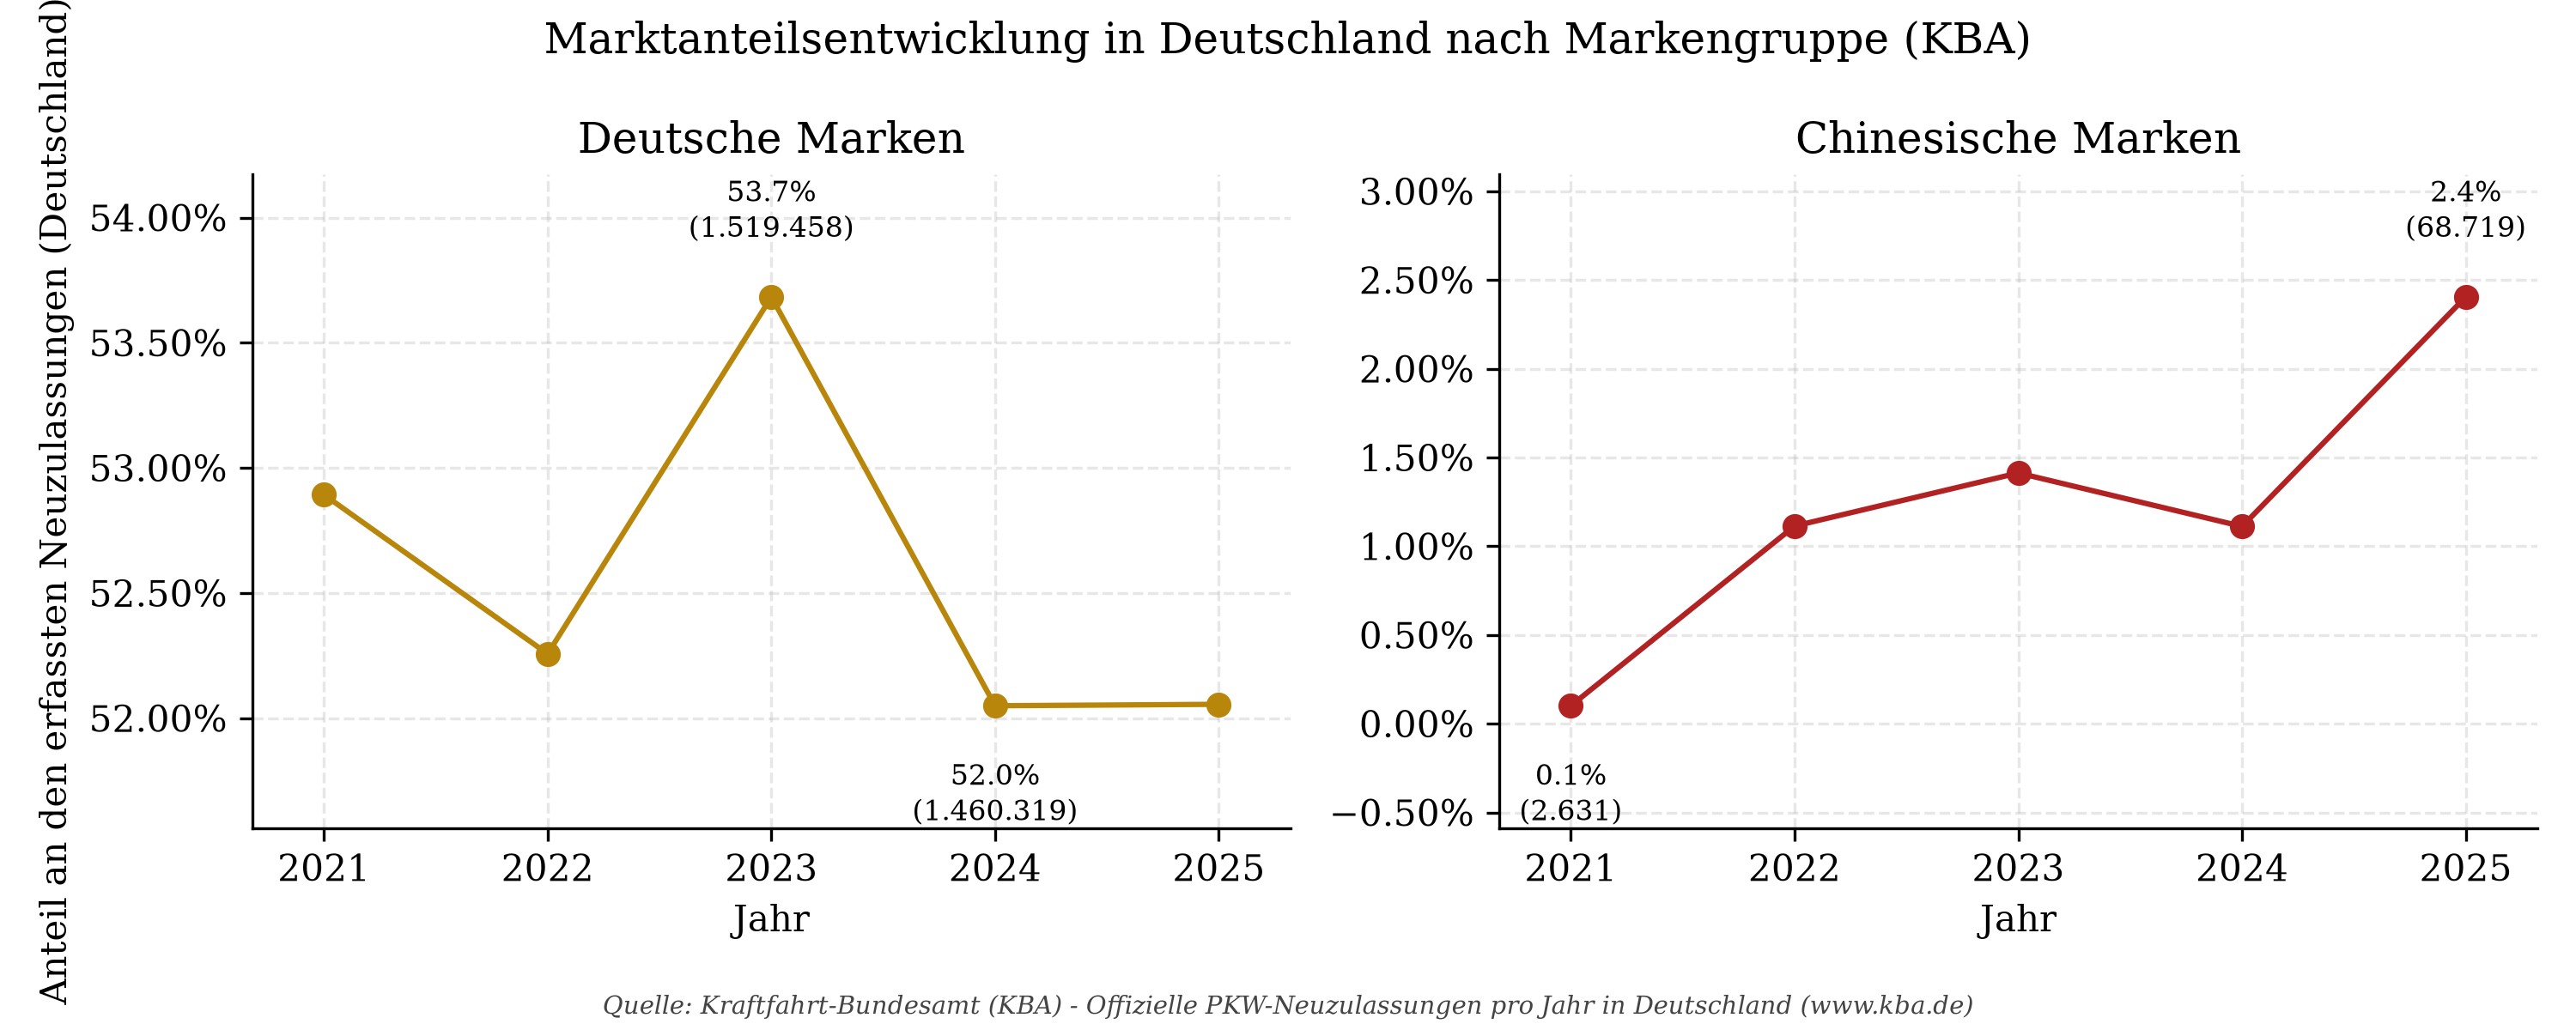

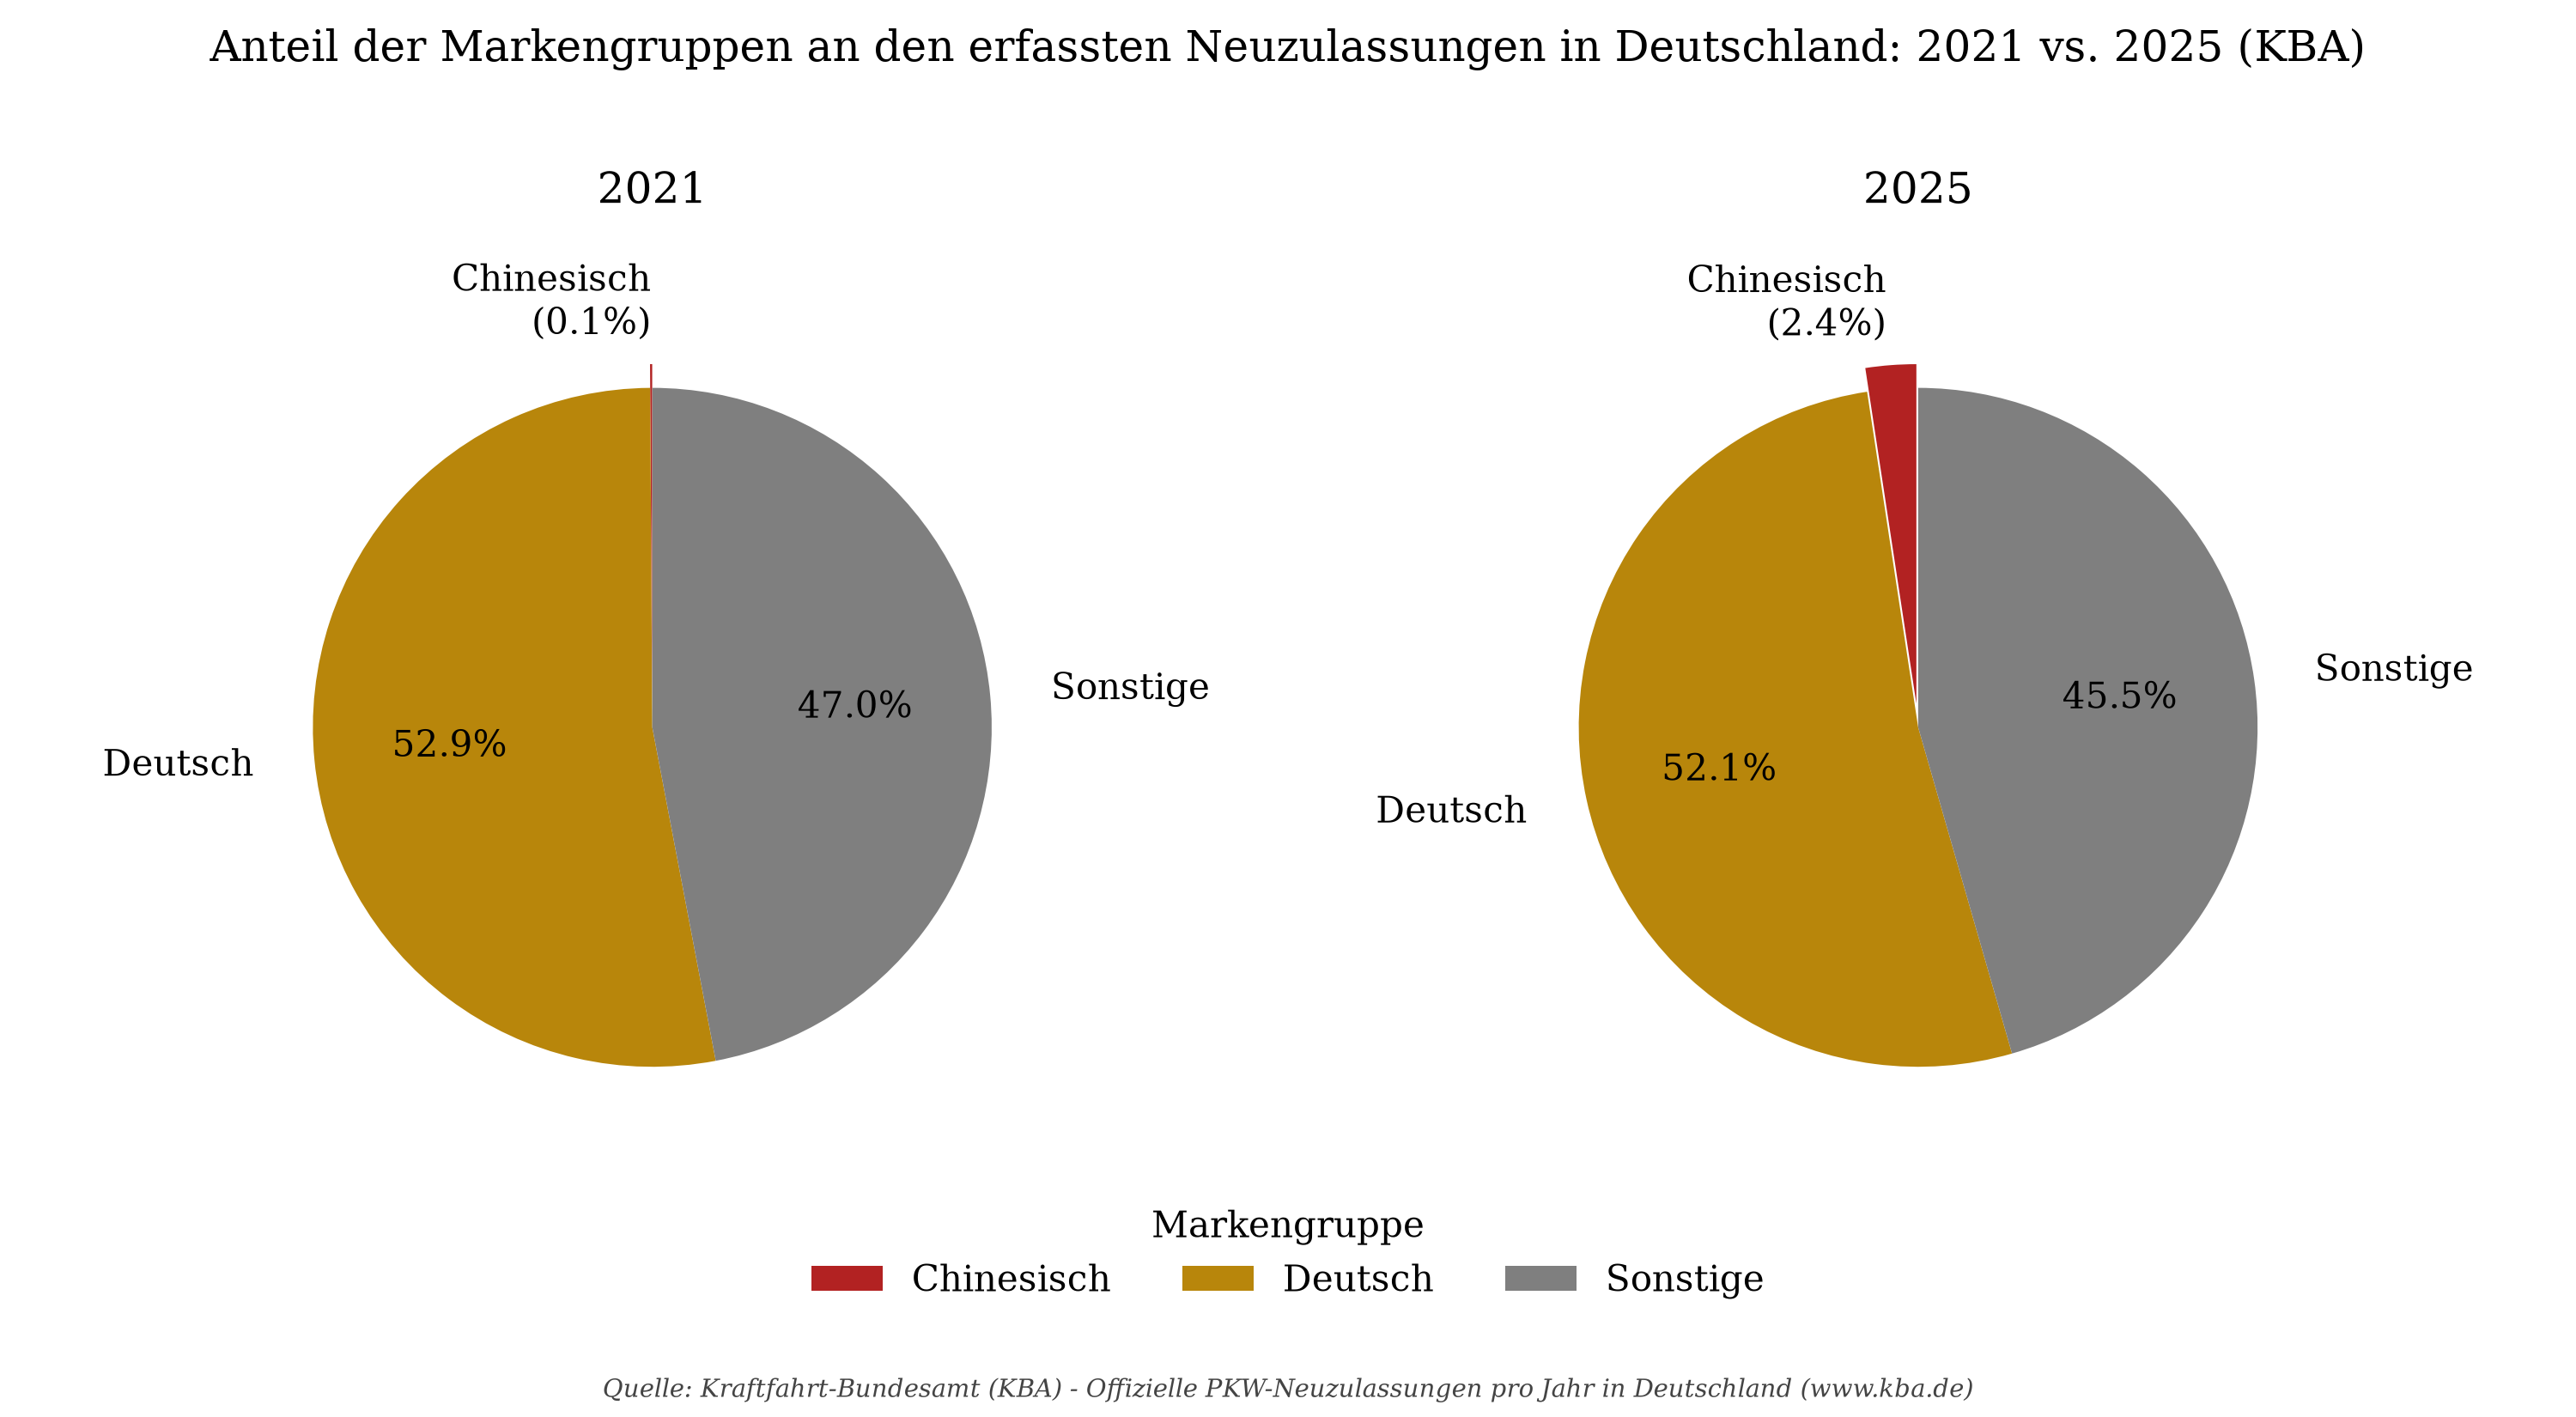

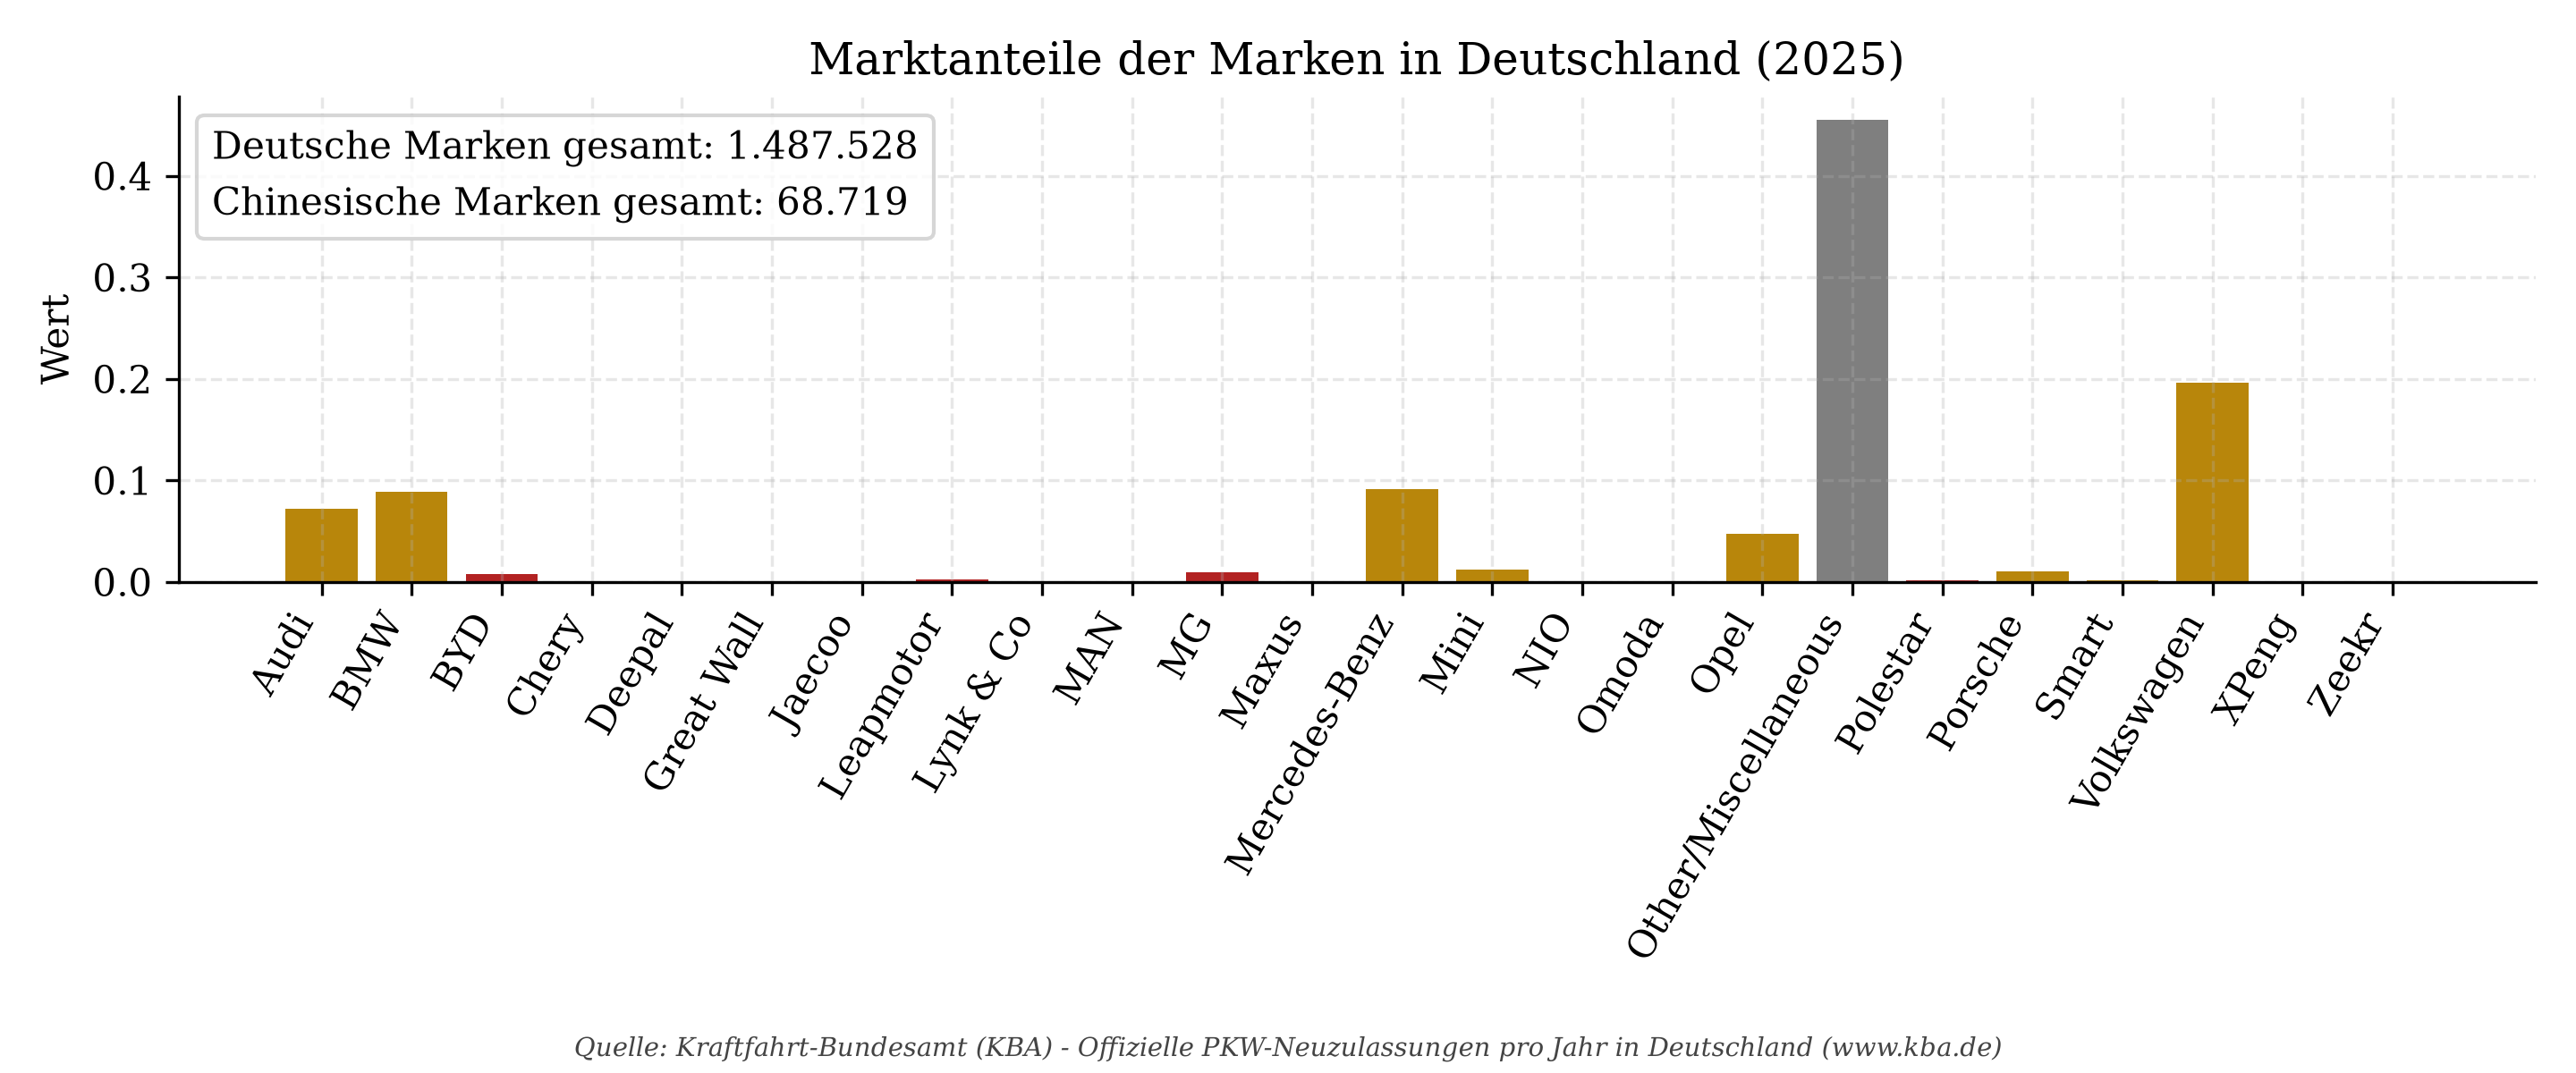

In [5]:
trend_path = plot_kba_registration_trend(
    frame, FIGURES_DIR / "trends" / "kba_registration_trend.png"
)
pie_path = plot_kba_share_pie_charts(frame, FIGURES_DIR / "trends" / "kba_share_pie_first_last.png")

latest_period = frame["reporting_period"].max()
latest = frame[frame["reporting_period"] == latest_period]
market_share = dict(zip(latest["canonical_brand"], latest["kba_registration_share"], strict=False))
brand_to_group = dict(zip(latest["canonical_brand"], latest["brand_group"], strict=False))
bar_colors = [
    BRAND_GROUP_COLORS.get(brand_to_group.get(brand), "#219ebc") for brand in market_share
]
group_totals = latest.groupby("brand_group")["brand_registrations"].sum()


def _format_german_thousands(value: float) -> str:
    return f"{int(round(value)):,}".replace(",", ".")


legend_notes = [
    f"Deutsche Marken gesamt: {_format_german_thousands(group_totals.get('german', 0))}",
    f"Chinesische Marken gesamt: {_format_german_thousands(group_totals.get('chinese', 0))}",
]
share_path = create_report_placeholder(
    FIGURES_DIR / "frequency" / "kba_market_share_latest.png",
    metrics=market_share,
    title=f"Marktanteile der Marken in Deutschland ({latest_period})",
    bar_colors=bar_colors,
    legend_notes=legend_notes,
)

display(Image(filename=str(trend_path)))
display(Image(filename=str(pie_path)))
display(Image(filename=str(share_path)))

## Zusammenfassung

Dieses Projekt misst ausschließlich tatsächliche Marktergebnisse (KBA-Neuzulassungen), nicht
Interesse, Stimmung oder Kaufabsicht. Belastbare Aussagen erfordern vollständige, über mehrere
Jahre reichende KBA-Zeitreihen sowie eine sorgfältige manuelle Prüfung nicht auflösbarer
Markennamen; Marktanteilsverschiebungen sollten nicht ohne weitere Kontextinformationen kausal
interpretiert werden. Zeitreihe und Abbildungen werden unter `artifacts/` gespeichert; die
Skripte unter `scripts/` (`download_kba_files.py`, `build_kba_annual_totals.py`,
`generate_all_figures.py`) bieten denselben Ablauf als reproduzierbare Kommandozeilen-Einstiegspunkte.


# Schweiz-Neuzulassungsanalyse

Dieser Abschnitt ergänzt die KBA-Analyse um eine zweite, unabhängige Datenquelle:
die nationalen Neuzulassungen von Personenwagen in der Schweiz (Bundesamt für Statistik / BFS,
zugrunde liegende Quelle: Bundesamt für Strassen ASTRA), verbreitet über die SDMX-REST-API von
stats.swiss. **Einordnung:** Diese Daten messen -- genau wie das KBA-Kapitel -- einen
**Neuzulassungsfluss** auf **nationaler Ebene**, sind also methodisch mit dem KBA-Kapitel
vergleichbar. Da die
Schweiz jedoch ein deutlich kleinerer Markt als Deutschland ist, sollten nur die **Anteile in
Prozent**, nicht die absoluten Zulassungszahlen, zwischen den beiden Ländern verglichen werden.

## Datengrundlage und Markennormalisierung

`ensure_ch_dataset()` lädt zwei reale Dateien von der stats.swiss-REST-API herunter, sofern sie
nicht bereits unter `data/raw/registrations/switzerland/` vorliegen: die Neuzulassungsdaten
selbst (nur nationale Summen, neue Fahrzeuge, alle Treibstoffarten, jährlich) sowie die
zugehörige Codeliste, die die numerischen Markencodes der API in Klarnamen übersetzt. Beide
werden zu einer getidyten Zeitreihe unter `data/interim/switzerland/ch_annual_brand_totals.csv`
zusammengefasst; bereits vorhandene Dateien werden dabei nicht erneut heruntergeladen bzw. neu
erzeugt. `build_ch_analysis_dataset()` normalisiert anschließend die rohen Markennamen
(`normalize_ch_brands`) gegen dieselbe `configs/brands.yaml` wie in den anderen Kapiteln. Marken,
die keiner deutschen oder chinesischen Marke zugeordnet werden können -- u. a. historische/
eingestellte Marken (Borgward, DKW, NSU, Trabant, Wartburg), Mehrdeutigkeiten (Mercedes-AMG,
Audi-Porsche) sowie alle übrigen realen Marken (Toyota, Ford, Hyundai, ...) -- werden nicht
geraten, sondern standardmäßig der Kategorie **Sonstige** zugeordnet, damit der Marktanteil
stets gegen die tatsächliche Gesamtsumme aller Marken berechnet wird.


In [6]:
# ensure_ch_dataset() reuses the tidied interim CSV if it already exists, and otherwise
# downloads the data file and MAKE codelist from the stats.swiss SDMX REST API only if
# not already present under data/raw/registrations/switzerland/ (never re-fetched once
# cached). Raises SourceUnavailableError with a clear required action if no real Swiss
# data can be found or downloaded -- there is no synthetic fallback of any kind.
ensure_ch_dataset()
ch_frame = build_ch_analysis_dataset(mode="cached")
ch_summary = create_dataset_summary(ch_frame, value_column="brand_registrations")
ch_summary

2026-07-15 17:59:17,246 | INFO | Swiss interim file already present at D:\Master\Projects\NLP_Projekt\Car_Trends\data\interim\switzerland\ch_annual_brand_totals.csv; nothing to download


2026-07-15 17:59:17,247 | INFO | Using tidied Swiss file at D:\Master\Projects\NLP_Projekt\Car_Trends\data\interim\switzerland\ch_annual_brand_totals.csv


2026-07-15 17:59:17,268 | INFO | Built Swiss registration series with 90 rows (mode=cached)


{'rows': 90,
 'columns': ['reporting_period',
  'canonical_brand',
  'brand_group',
  'brand_registrations',
  'all_new_registrations_switzerland',
  'ch_registration_share',
  'source_type',
  'source_name',
  'source_url',
  'source_record_id',
  'retrieved_at',
  'parser_version',
  'raw_file_path',
  'raw_file_hash',
  'license_or_usage_note',
  'collection_method'],
 'reporting_period_start': '2021',
 'reporting_period_end': '2025',
 'brand_group_counts': {'german': 45, 'chinese': 40, 'other': 5},
 'total_by_brand': {'Other/Miscellaneous': 685538,
  'Volkswagen': 128357,
  'BMW': 103335,
  'Mercedes-Benz': 97808,
  'Audi': 89811,
  'Porsche': 22118,
  'Opel': 20621,
  'Mini': 18751,
  'MG': 4358,
  'Polestar': 4232,
  'Smart': 3088,
  'BYD': 1007,
  'Leapmotor': 939,
  'JAC': 815,
  'Aiways': 202,
  'Zeekr': 132,
  'MAN': 115,
  'Skywell': 104,
  'Seres': 78,
  'Voyah': 69,
  'XPeng': 60,
  'Maxus': 21,
  'NIO': 2,
  'Omoda': 1}}

In [7]:
latest_period_ch = ch_frame["reporting_period"].max()
other_share_ch = ch_frame.loc[
    (ch_frame["reporting_period"] == latest_period_ch) & (ch_frame["brand_group"] == "other"),
    "ch_registration_share",
].sum()
print(
    f"'Sonstige' deckt im aktuellsten Berichtsjahr ({latest_period_ch}) einen Anteil von "
    f"{other_share_ch:.1%} der erfassten Neuzulassungen ab."
)

'Sonstige' deckt im aktuellsten Berichtsjahr (2025) einen Anteil von 56.5% der erfassten Neuzulassungen ab.


## Marktanteilsentwicklung je Marke

Die Tabelle unten zeigt je Marke und Berichtsjahr den Marktanteil (`ch_registration_share`)
sowie dessen Veränderung gegenüber der jeweils vorherigen Periode.


In [8]:
ch_trend = ch_frame.sort_values(["canonical_brand", "reporting_period"]).copy()
ch_trend["share_change_vs_previous_period"] = ch_trend.groupby("canonical_brand")[
    "ch_registration_share"
].diff()
ch_trend[
    [
        "reporting_period",
        "canonical_brand",
        "brand_group",
        "ch_registration_share",
        "share_change_vs_previous_period",
    ]
].tail(10)

,reporting_period,canonical_brand,brand_group,ch_registration_share,share_change_vs_previous_period
13,2021,Volkswagen,german,0.107999,NaN
27,2022,Volkswagen,german,0.112391,0.004392
44,2023,Volkswagen,german,0.112378,-0.000013
64,2024,Volkswagen,german,0.100515,-0.011863
86,2025,Volkswagen,german,0.109922,0.009407
45,2023,Voyah,chinese,0.000084,NaN
65,2024,Voyah,chinese,0.000126,0.000042
87,2025,Voyah,chinese,0.000077,-0.000049
88,2025,XPeng,chinese,0.000258,NaN
89,2025,Zeekr,chinese,0.000567,NaN


## Abbildungen

Dieselben drei Abbildungstypen wie in den vorherigen Kapiteln, hier für die Schweizer
Neuzulassungen: ein Liniendiagramm mit getrennten Skalen für deutsche und chinesische Marken,
ein Kreisdiagramm-Vergleich zwischen dem ersten und letzten Beobachtungsjahr sowie ein
Balkendiagramm mit dem Marktanteil je Marke im aktuellsten Berichtsjahr.


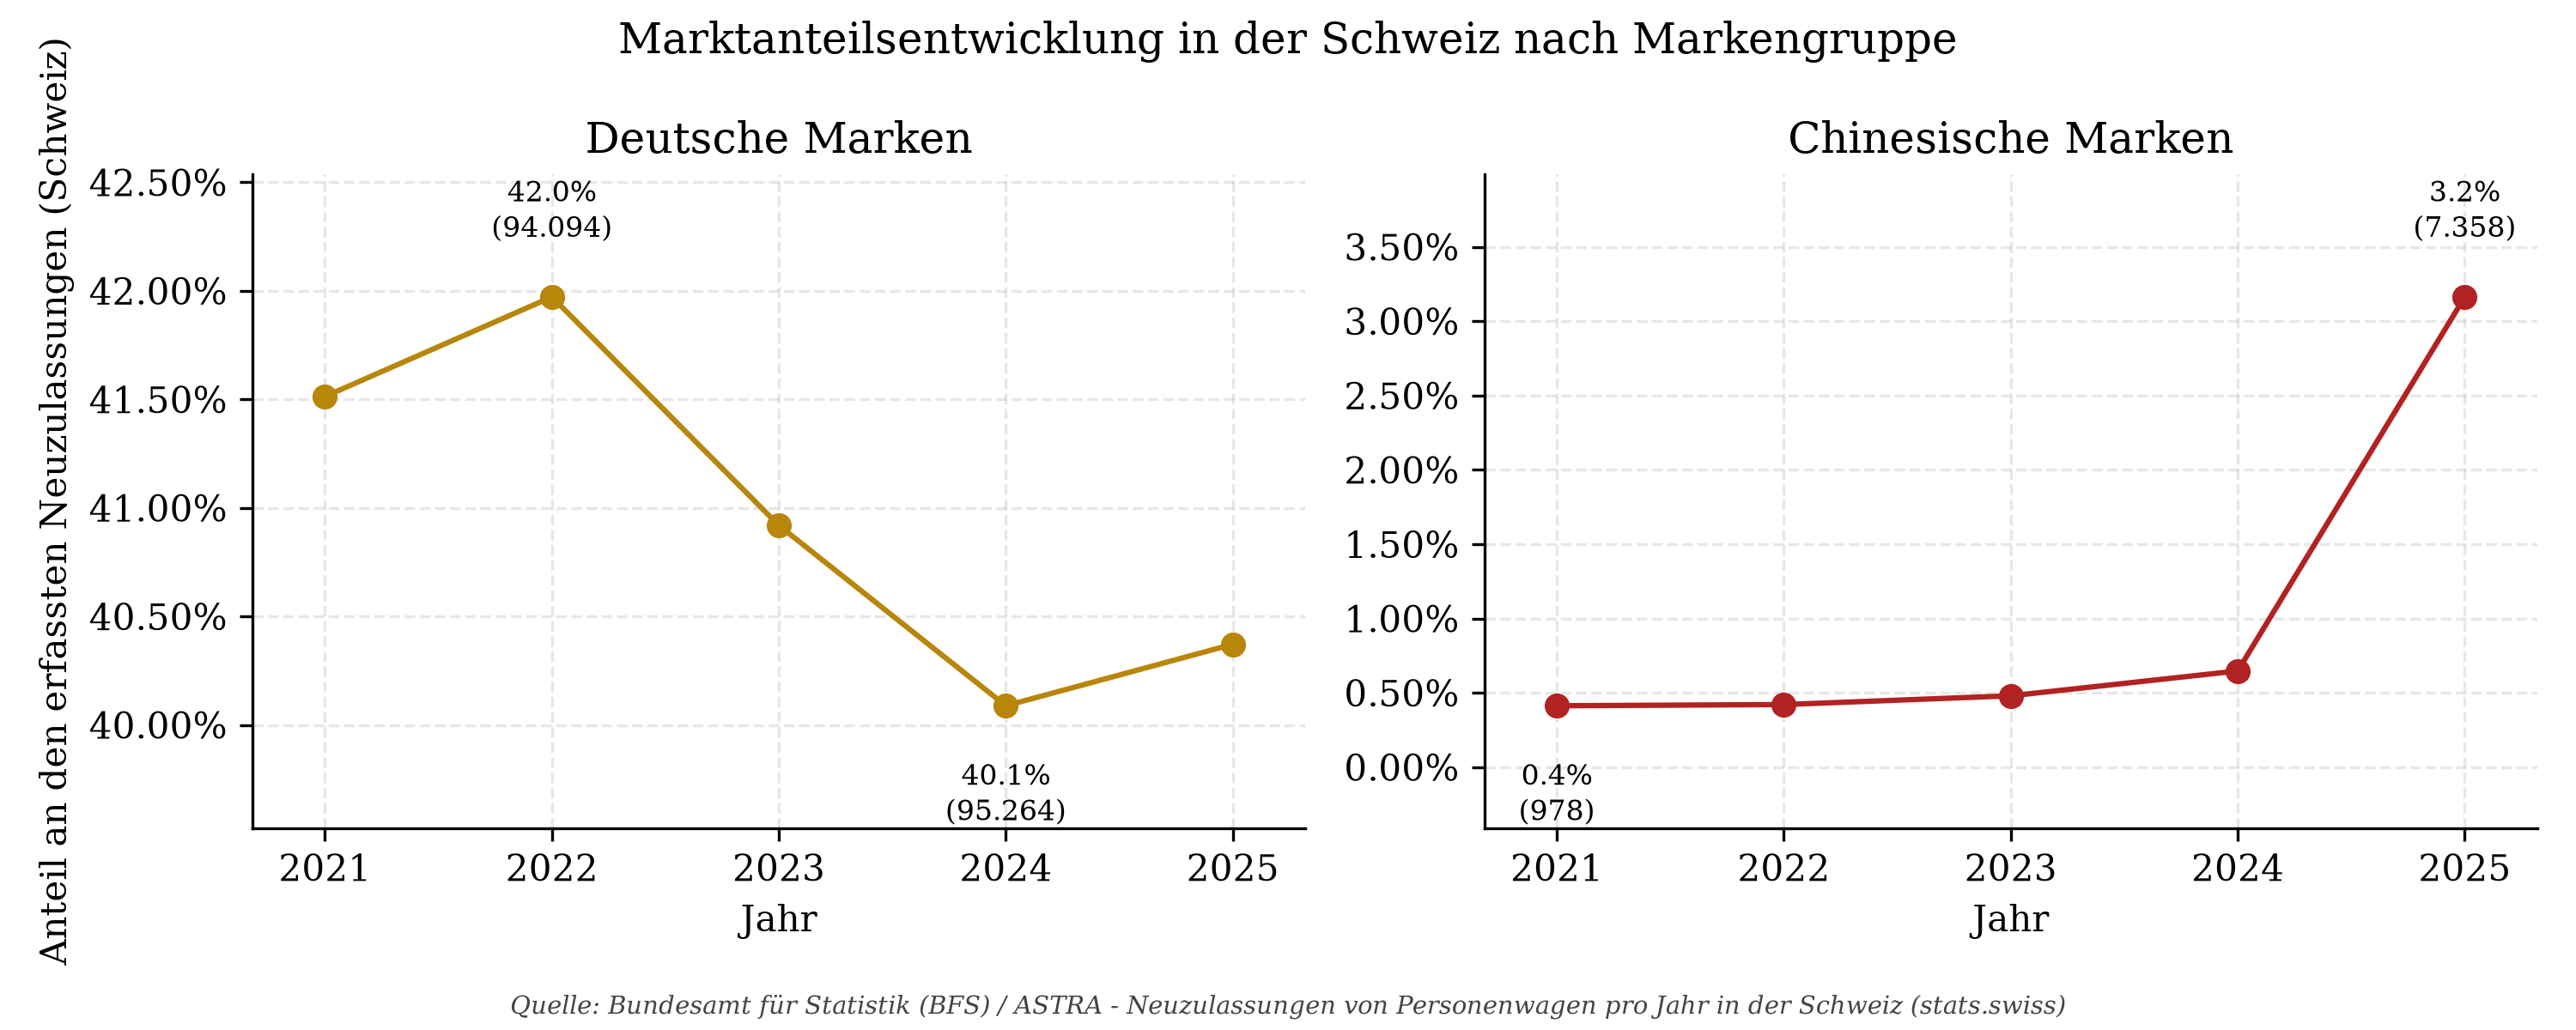

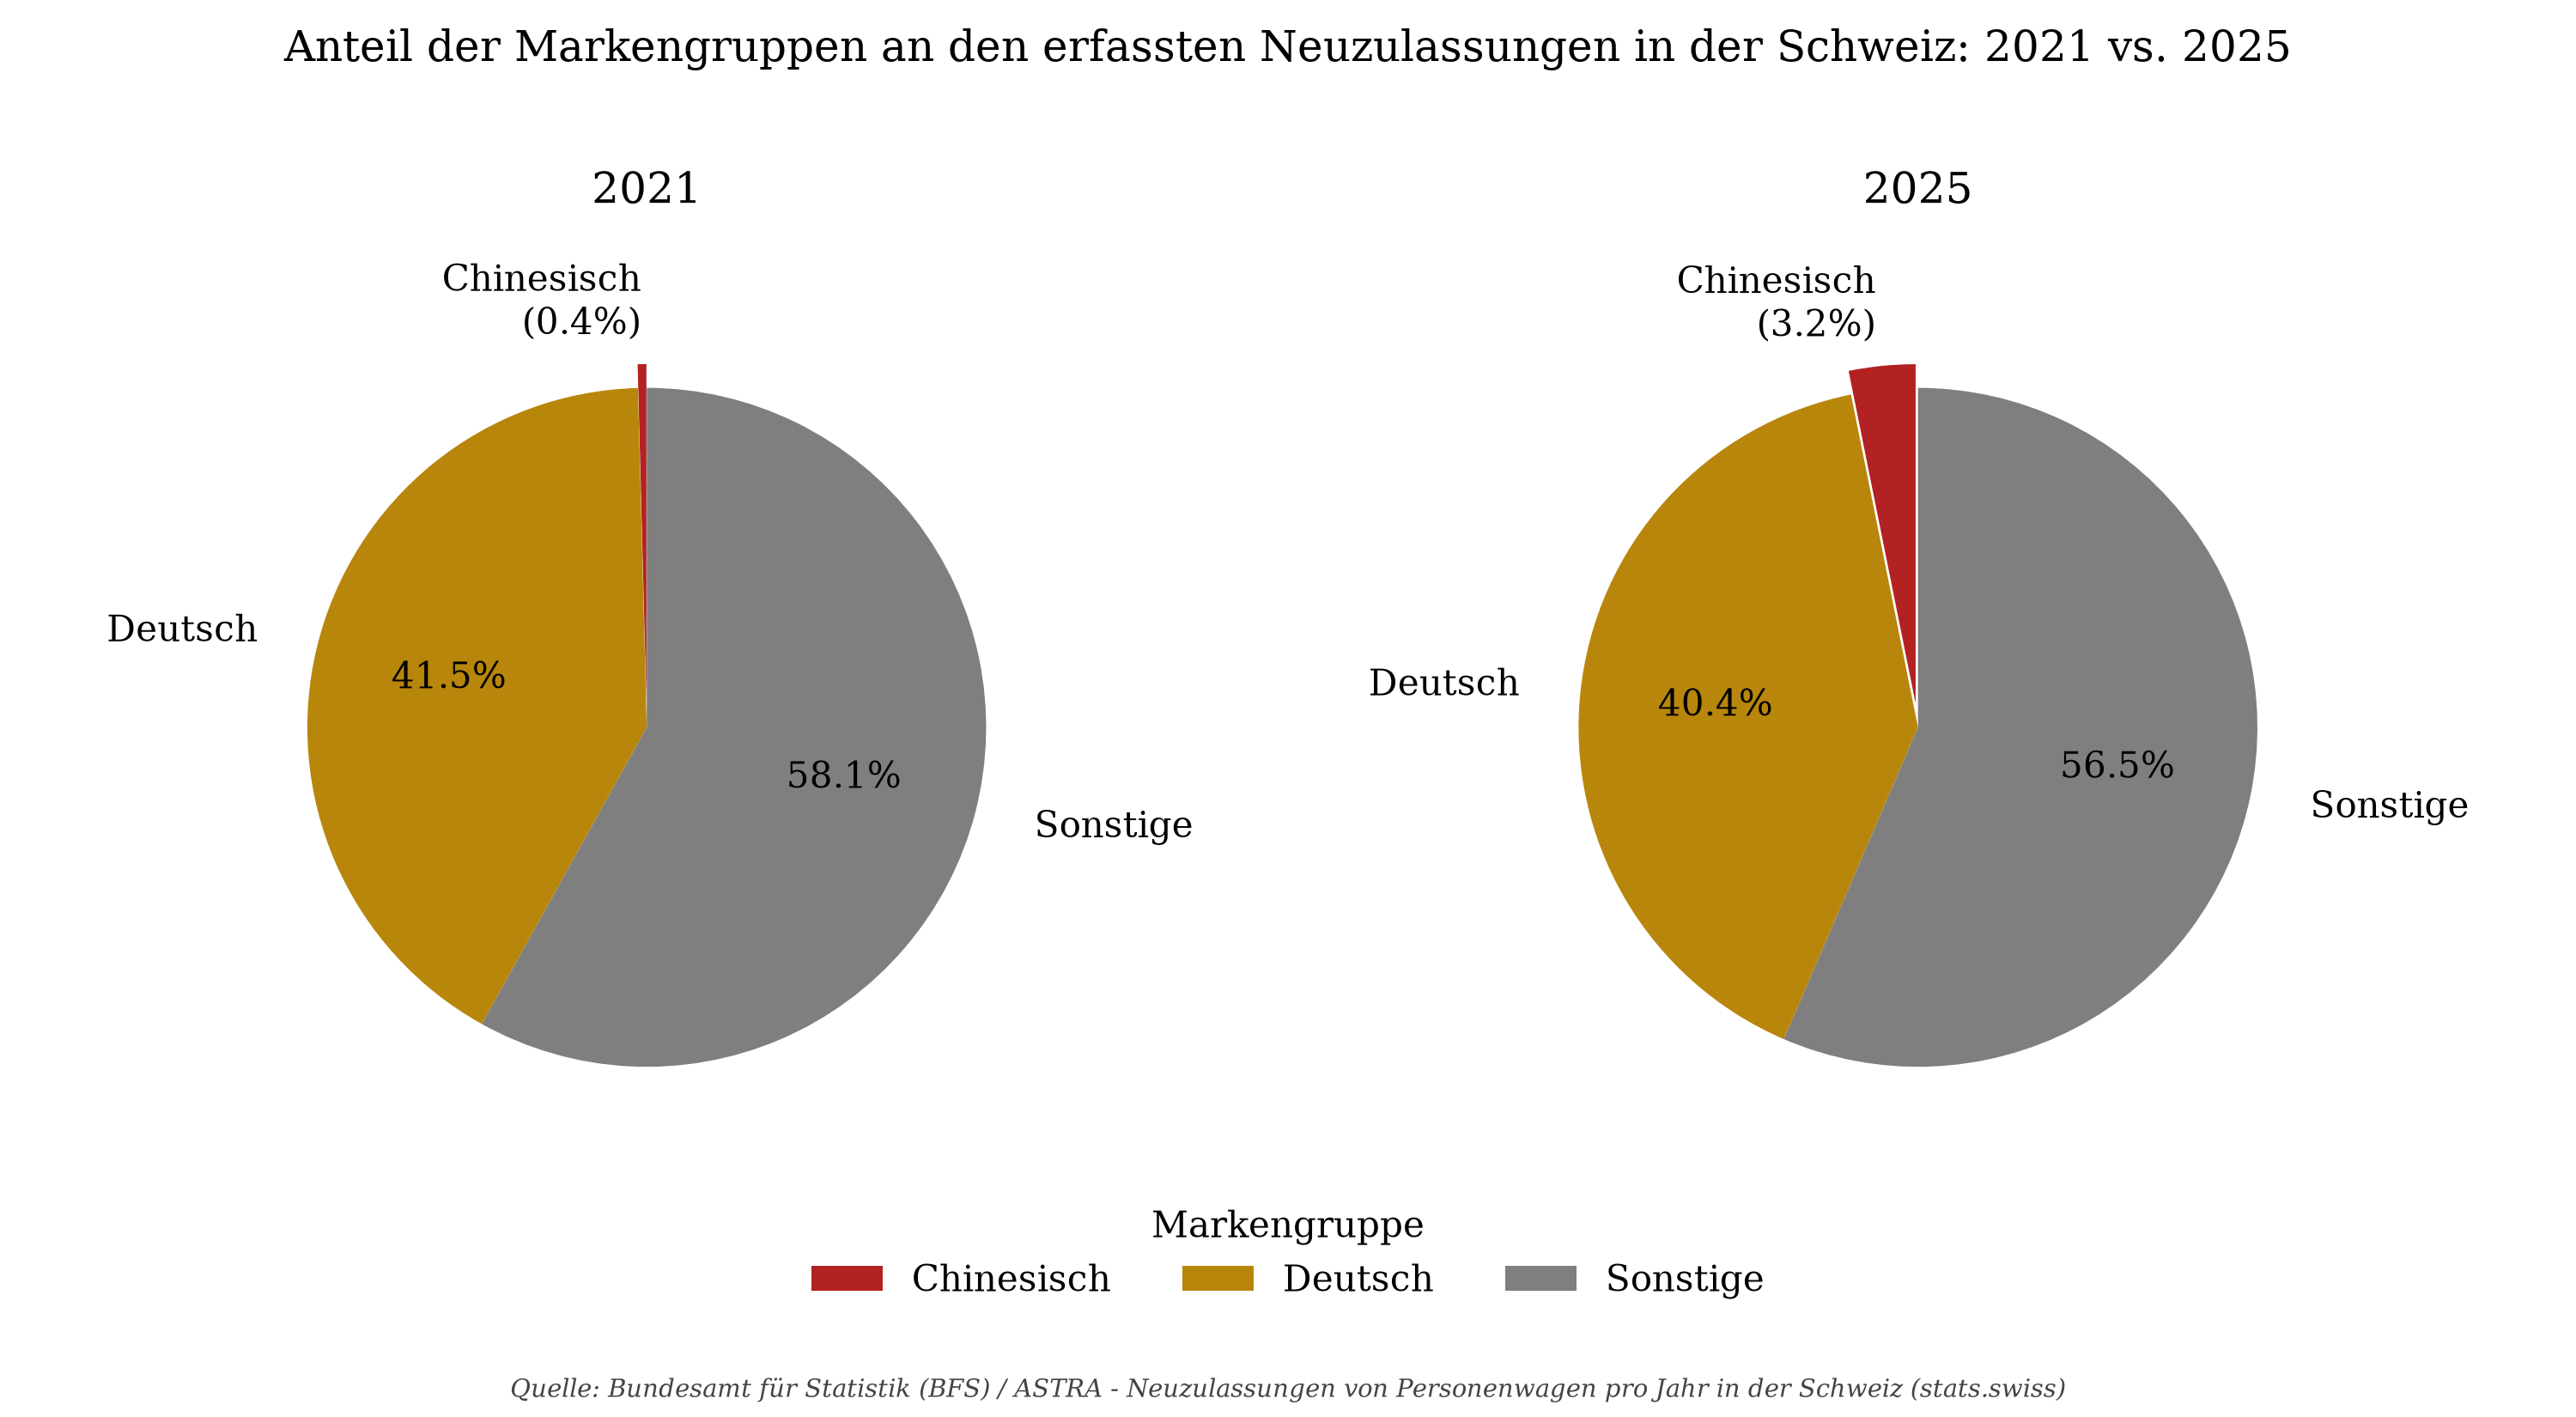

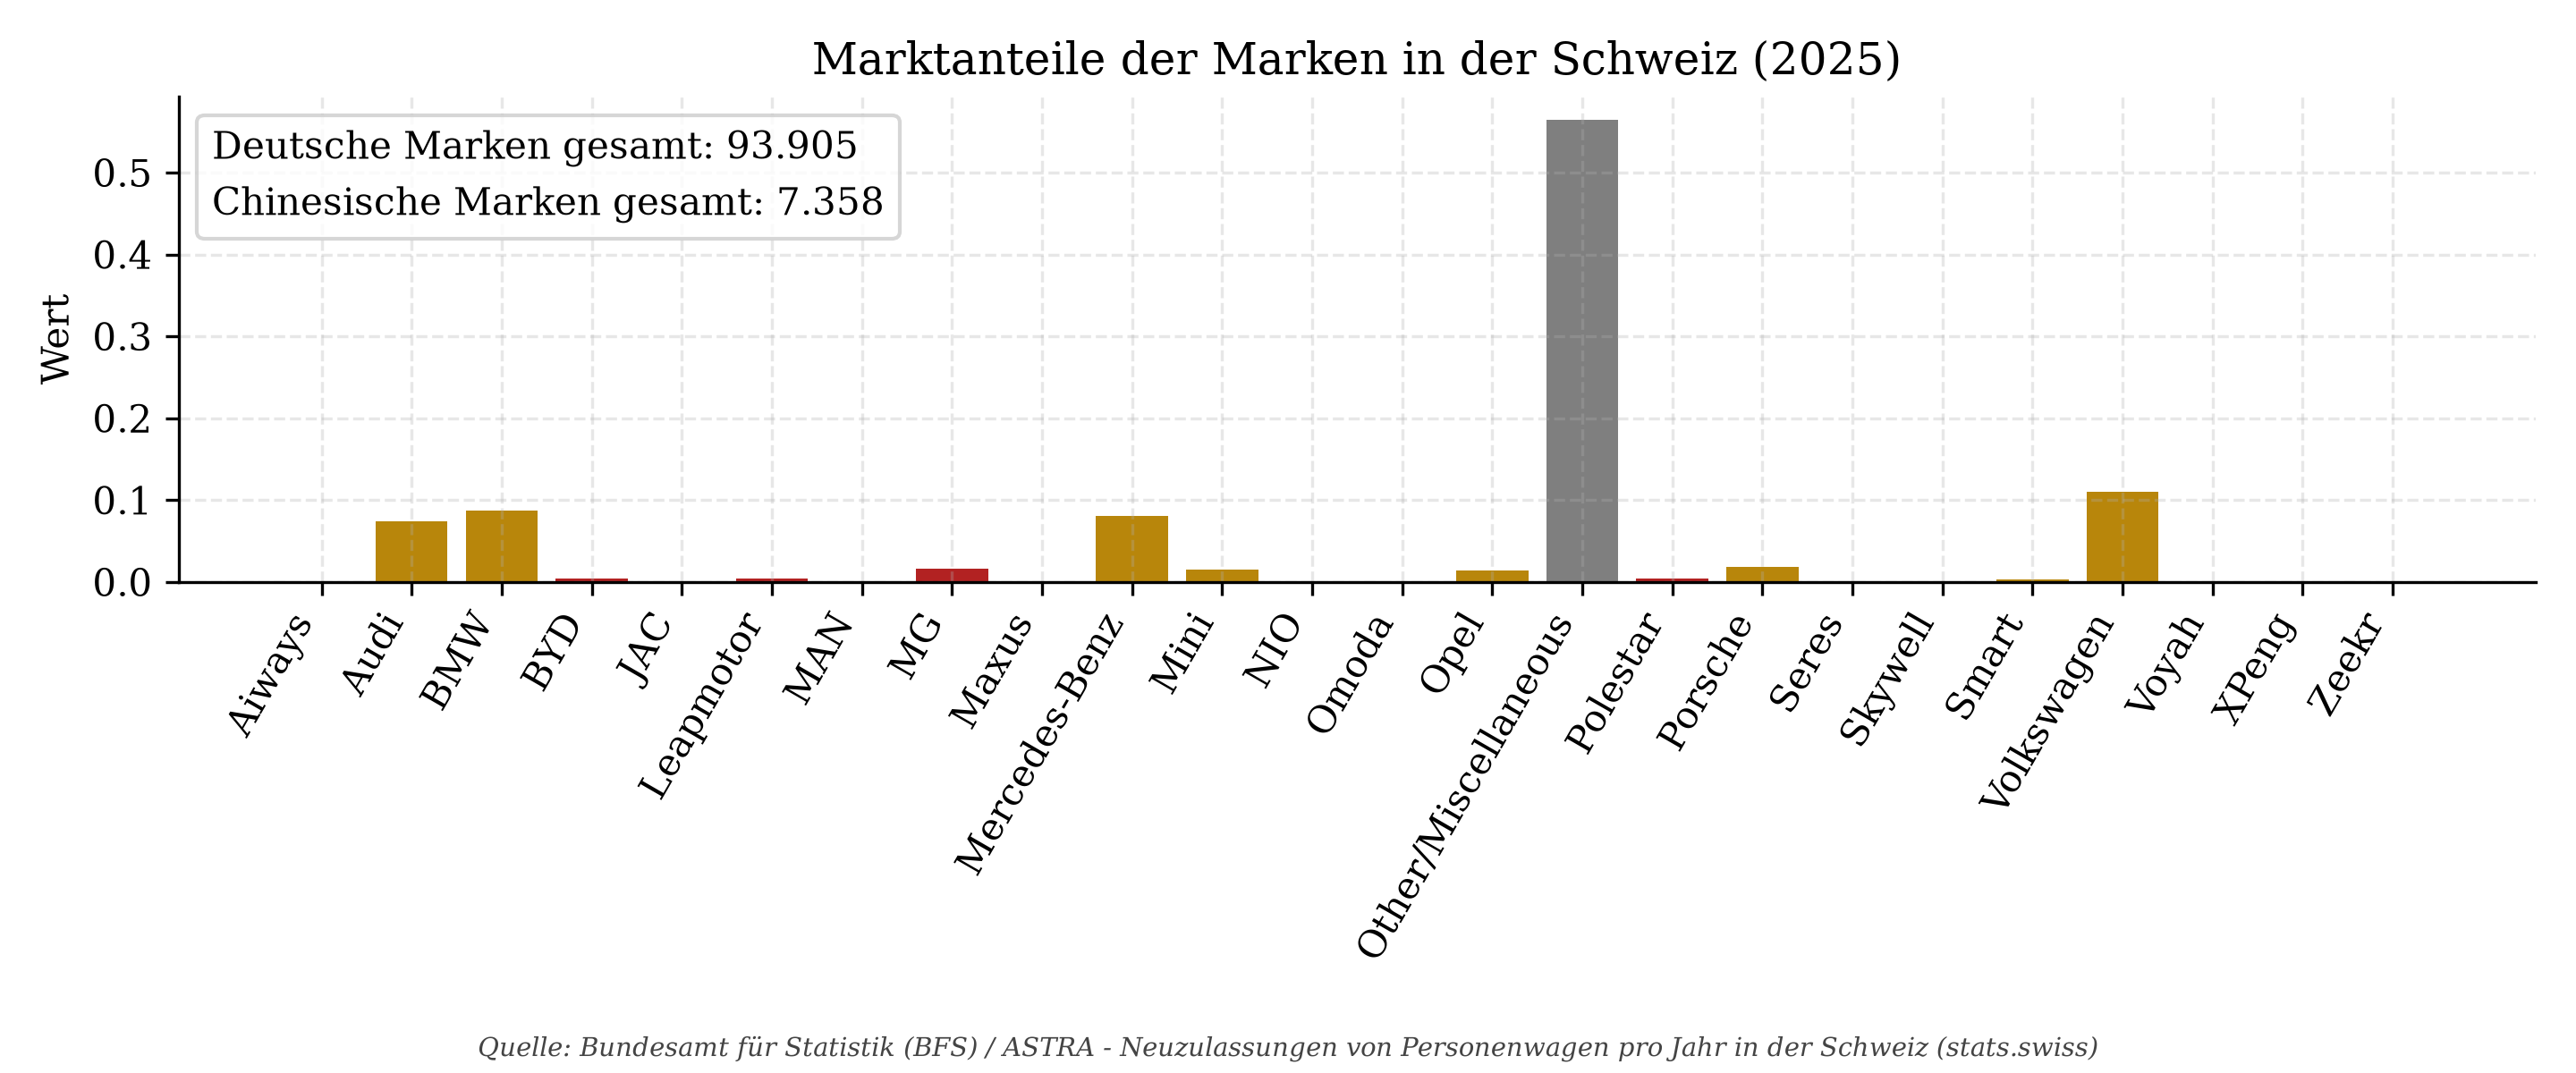

In [9]:
ch_trend_path = plot_kba_registration_trend(
    ch_frame,
    FIGURES_DIR / "trends" / "ch_registration_trend.png",
    share_column="ch_registration_share",
    y_label="Anteil an den erfassten Neuzulassungen (Schweiz)",
    suptitle="Marktanteilsentwicklung in der Schweiz nach Markengruppe",
    source_note=CH_SOURCE_NOTE,
)

ch_first_period = ch_frame["reporting_period"].min()
ch_last_period = ch_frame["reporting_period"].max()
ch_pie_path = plot_kba_share_pie_charts(
    ch_frame,
    FIGURES_DIR / "trends" / "ch_share_pie_first_last.png",
    share_column="ch_registration_share",
    suptitle=(
        "Anteil der Markengruppen an den erfassten Neuzulassungen in der Schweiz: "
        f"{ch_first_period} vs. {ch_last_period}"
    ),
    source_note=CH_SOURCE_NOTE,
)

ch_latest = ch_frame[ch_frame["reporting_period"] == ch_last_period]
ch_market_share = dict(
    zip(ch_latest["canonical_brand"], ch_latest["ch_registration_share"], strict=False)
)
ch_brand_to_group = dict(zip(ch_latest["canonical_brand"], ch_latest["brand_group"], strict=False))
ch_bar_colors = [
    BRAND_GROUP_COLORS.get(ch_brand_to_group.get(brand), "#219ebc") for brand in ch_market_share
]
ch_group_totals = ch_latest.groupby("brand_group")["brand_registrations"].sum()
ch_legend_notes = [
    f"Deutsche Marken gesamt: {_format_german_thousands(ch_group_totals.get('german', 0))}",
    f"Chinesische Marken gesamt: {_format_german_thousands(ch_group_totals.get('chinese', 0))}",
]
ch_share_path = create_report_placeholder(
    FIGURES_DIR / "frequency" / "ch_market_share_latest.png",
    metrics=ch_market_share,
    title=f"Marktanteile der Marken in der Schweiz ({ch_last_period})",
    bar_colors=ch_bar_colors,
    legend_notes=ch_legend_notes,
    source_note=CH_SOURCE_NOTE,
)

display(Image(filename=str(ch_trend_path)))
display(Image(filename=str(ch_pie_path)))
display(Image(filename=str(ch_share_path)))

## Zusammenfassung

Die Schweizer Neuzulassungen bestätigen dieselbe Grundtendenz wie das KBA-Kapitel -- ein
wachsender, aber weiterhin kleiner Anteil chinesischer Marken gegenüber einer nach wie vor
dominanten deutschen Markengruppe --, gemessen an einer unabhängigen, aber methodisch
vergleichbaren nationalen Neuzulassungsstatistik. Da die Schweiz ein deutlich kleinerer Markt
ist als Deutschland, sind nur die Marktanteile in Prozent vergleichbar, nicht die absoluten
Zulassungszahlen. Zeitreihe und Abbildungen werden unter `artifacts/` gespeichert; `scripts/download_ch_registrations.py` und `scripts/generate_ch_figures.py` bieten denselben
Ablauf als reproduzierbare Kommandozeilen-Einstiegspunkte.


# Google Trends-Suchinteresse-Analyse

Dieser Abschnitt ergänzt die beiden Neuzulassungs-Kapitel um eine dritte, unabhängige
Datenquelle: den öffentlichen relativen Suchinteresse-Index von Google Trends
(trends.google.com), abgefragt für **Volkswagen** und **BYD** (Geo: weltweit, konfigurierbar
über `configs/sources.yaml`'s `google_trends.geo`; Zeitraum: 2021-2025, wie die KBA-/
Schweiz-Kapitel). **Einordnung:** Anders als die KBA- und Schweiz-Kapitel misst dieser Abschnitt
kein reales Marktergebnis, sondern öffentliches Sucheinteresse -- was Menschen online suchen,
nicht was sie tatsächlich kaufen. Ein hoher oder steigender Suchinteresse-Anteil ist daher kein
Beleg für einen entsprechenden Marktanteil.

## Bewusst auf zwei Marken begrenzt

Anders als die KBA- und Schweiz-Kapitel deckt dieser Abschnitt **nicht** alle in
`configs/brands.yaml` erfassten deutschen und chinesischen Marken ab, sondern ist bewusst auf
**Volkswagen** (deutsch) und **BYD** (chinesisch) begrenzt -- je die klarste, eindeutigste
Flaggschiff-Marke ihrer Gruppe. Grund sind zwei technische Einschränkungen der (inoffiziellen)
Google-Trends-Schnittstelle:

1. Google Trends beantwortet höchstens 5 Suchbegriffe pro Anfrage und drosselt/blockiert die
   inoffizielle Schnittstelle (`pytrends`, da Google keine offizielle Trends-API anbietet)
   aggressiv -- eine vollständige Abfrage aller ca. 30 erfassten Marken würde viele
   Anfrage-Gruppen benötigen und ist als zuverlässige Datenquelle nicht praktikabel.
2. Mehrere erfasste Markennamen sind als reine Suchbegriffe mehrdeutig (z. B. "Mini", "Smart",
   "MAN", "MG", "Ora" sind auch gängige Wörter/Abkürzungen ohne Auto-Bezug) und würden das
   Sucheinteresse-Signal verrauschen.

Dieses Kapitel liefert daher **keinen umfassenden Markenvergleich**, sondern einen
**richtungsweisenden Indikator** für das Sucheinteresse an der jeweils bekanntesten deutschen
und chinesischen Automarke -- entsprechend zeigen die Abbildungen unten Volkswagen und BYD
namentlich, nicht generische Markengruppen-Bezeichnungen wie in den KBA-/Schweiz-Kapiteln (dort
korrekt, da diese echte Vielmarken-Aggregate sind; hier wäre das irreführend, da es sich um
jeweils genau eine Marke pro Gruppe handelt). Details dazu stehen auch im README unter
"Google Trends".

## Manuell exportierte Daten (statt automatisiertem Abruf)

Beim Aufbau dieses Kapitels hat die automatisierte Abfrage über `pytrends` wiederholt reale
HTTP-429-Fehler (`USER_TYPE_EMBED_OVER_QUOTA`) erhalten -- auch nach exponentiellem Backoff von
bis zu 120 Sekunden zwischen den Versuchen. Das ist Googles anonymes Trends-Kontingent, kein
Fehler in diesem Projekt. `ensure_trends_dataset()` unterstützt daher gleichwertig eine von Hand
über die Trends-Weboberfläche exportierte CSV-Datei (Button "CSV herunterladen" auf
trends.google.com) unter `data/raw/trends/google_trends_manual_export.csv` -- genau so ist die
in diesem Repository aktuell verwendete Zeitreihe entstanden (siehe README's
"Google Trends: Option B"). Google beschriftet Spalten in einem solchen Export mit seinem
eigenen, disambiguierten Suchbegriff-Namen (z. B. **"BYD Auto"** statt "BYD"); dies wird über
einen zusätzlichen Alias-Eintrag in `configs/brands.yaml` aufgelöst.

## Datengrundlage und Skalierung

Da nur zwei Marken abgefragt werden, passen beide in eine einzige Google-Trends-Anfrage (die
höchstens 5 Suchbegriffe erlaubt) -- die Mehrfach-Anfrage-Verkettung über eine gemeinsame
Ankermarke (`chain_trends_batches()` in `src/car_interest_nlp/data/google_trends.py`), die für
eine größere Markenanzahl nötig wäre, kommt hier im Regelfall nicht zum Einsatz (der Code
unterstützt sie weiterhin, falls `configs/sources.yaml`'s `google_trends.tracked_brands` später
erweitert wird).

`configs/sources.yaml`'s `google_trends.timeframe` ("today 5-y") ist relativ zum Abfrage-/
Exportzeitpunkt und enthält deshalb immer den bereits verstrichenen Teil des laufenden Jahres
(z. B. ein Export im Juli 2026 enthält Januar-Juli 2026 als unvollständiges Jahr).
`annualize_trends_series()` verwirft daher jedes Jahr nach `google_trends.end_year` (Standard
2025, siehe `TRENDS_DEFAULT_END_YEAR`) -- **dieses Kapitel vergleicht daher wie die KBA-/
Schweiz-Kapitel 2021-2025**, nicht das unvollständige laufende Jahr.

`ensure_trends_dataset()` verwendet die manuell exportierte Datei, sofern vorhanden (siehe oben),
und lädt andernfalls die echten Rohdaten von Google Trends herunter -- in beiden Fällen werden
sie zu einem jährlichen Index je Marke unter
`data/interim/trends/google_trends_brand_interest.csv` aggregiert.
`build_trends_analysis_dataset()` löst die verwendeten Suchbegriffe anschließend gegen dieselbe
`configs/brands.yaml` wie in den anderen Kapiteln auf. Da jeder Suchbegriff bereits direkt aus
`configs/brands.yaml` stammt bzw. über einen Alias-Eintrag darauf zurückgeführt wird (keine
rohen, mehrdeutigen Markenstrings wie bei KBA/Schweiz), gibt es hier -- anders als in den
anderen Kapiteln -- **keine "Sonstige"-Kategorie**.

**Wichtiger Unterschied zu `kba_registration_share`/`ch_registration_share`:**
`google_trends_interest_share` ist hier schlicht der Anteil von Volkswagen bzw. BYD am
gemeinsamen Sucheinteresse dieser beiden Marken -- nicht am gesamten Google-Suchvolumen (eine
solche Gesamtgröße ist nicht messbar) und erst recht nicht am Suchinteresse aller Automarken.
Diese Prozentzahl hat also einen anderen Nenner als die Neuzulassungs-Kapitel und darf nicht
direkt mit deren Marktanteilen verglichen werden.


In [10]:
# ensure_trends_dataset() reuses the tidied interim CSV if it already exists, and otherwise
# fetches only the keyword batches still missing under data/raw/trends/ (already-fetched
# batches are never re-fetched). This can take several minutes and may need to be re-run if
# Google's unofficial Trends endpoint rate-limits/blocks a batch -- it raises
# SourceUnavailableError listing exactly which batches are still missing rather than
# silently using partial or synthetic data.
ensure_trends_dataset()
trends_frame = build_trends_analysis_dataset(mode="cached")
trends_summary = create_dataset_summary(trends_frame, value_column="search_interest_index")
trends_summary

2026-07-15 17:59:18,071 | INFO | Google Trends interim file already present at D:\Master\Projects\NLP_Projekt\Car_Trends\data\interim\trends\google_trends_brand_interest.csv; nothing to download


2026-07-15 17:59:18,071 | INFO | Using tidied Google Trends file at D:\Master\Projects\NLP_Projekt\Car_Trends\data\interim\trends\google_trends_brand_interest.csv


2026-07-15 17:59:18,084 | INFO | Built Google Trends search-interest series with 10 rows (mode=cached)


{'rows': 10,
 'columns': ['reporting_period',
  'canonical_brand',
  'brand_group',
  'search_interest_index',
  'all_tracked_brand_interest',
  'google_trends_interest_share',
  'source_type',
  'source_name',
  'source_url',
  'source_record_id',
  'retrieved_at',
  'parser_version',
  'raw_file_path',
  'raw_file_hash',
  'license_or_usage_note',
  'collection_method'],
 'reporting_period_start': '2021',
 'reporting_period_end': '2025',
 'brand_group_counts': {'chinese': 5, 'german': 5},
 'total_by_brand': {'Volkswagen': 375.5833333333333, 'BYD': 43.33333333333333}}

## Entwicklung des Suchinteresses je Marke

Die Tabelle unten zeigt je Marke und Berichtsjahr den Anteil am erfassten Suchinteresse
(`google_trends_interest_share`) sowie dessen Veränderung gegenüber dem jeweils vorherigen
Jahr.


In [11]:
trends_trend = trends_frame.sort_values(["canonical_brand", "reporting_period"]).copy()
trends_trend["share_change_vs_previous_period"] = trends_trend.groupby("canonical_brand")[
    "google_trends_interest_share"
].diff()
trends_trend[
    [
        "reporting_period",
        "canonical_brand",
        "brand_group",
        "google_trends_interest_share",
        "share_change_vs_previous_period",
    ]
].tail(10)

,reporting_period,canonical_brand,brand_group,google_trends_interest_share,share_change_vs_previous_period
0,2021,BYD,chinese,0.018182,NaN
2,2022,BYD,chinese,0.025913,0.007731
4,2023,BYD,chinese,0.063073,0.037161
6,2024,BYD,chinese,0.115591,0.052518
8,2025,BYD,chinese,0.227481,0.111890
1,2021,Volkswagen,german,0.981818,NaN
3,2022,Volkswagen,german,0.974087,-0.007731
5,2023,Volkswagen,german,0.936927,-0.037161
7,2024,Volkswagen,german,0.884409,-0.052518
9,2025,Volkswagen,german,0.772519,-0.111890


## Abbildungen

Dieselben drei Abbildungstypen wie in den vorherigen Kapiteln, hier für das Google-Trends-
Suchinteresse an Volkswagen vs. BYD: ein Liniendiagramm mit getrennten Skalen für die deutsche
und die chinesische Marke, ein Kreisdiagramm-Vergleich zwischen dem ersten und letzten
Beobachtungsjahr sowie ein Balkendiagramm mit dem Anteil je Marke im aktuellsten Berichtsjahr.
Die y-Achsen zeigen hier den Anteil am erfassten *Suchinteresse* der beiden Marken, nicht deren
Marktanteil.


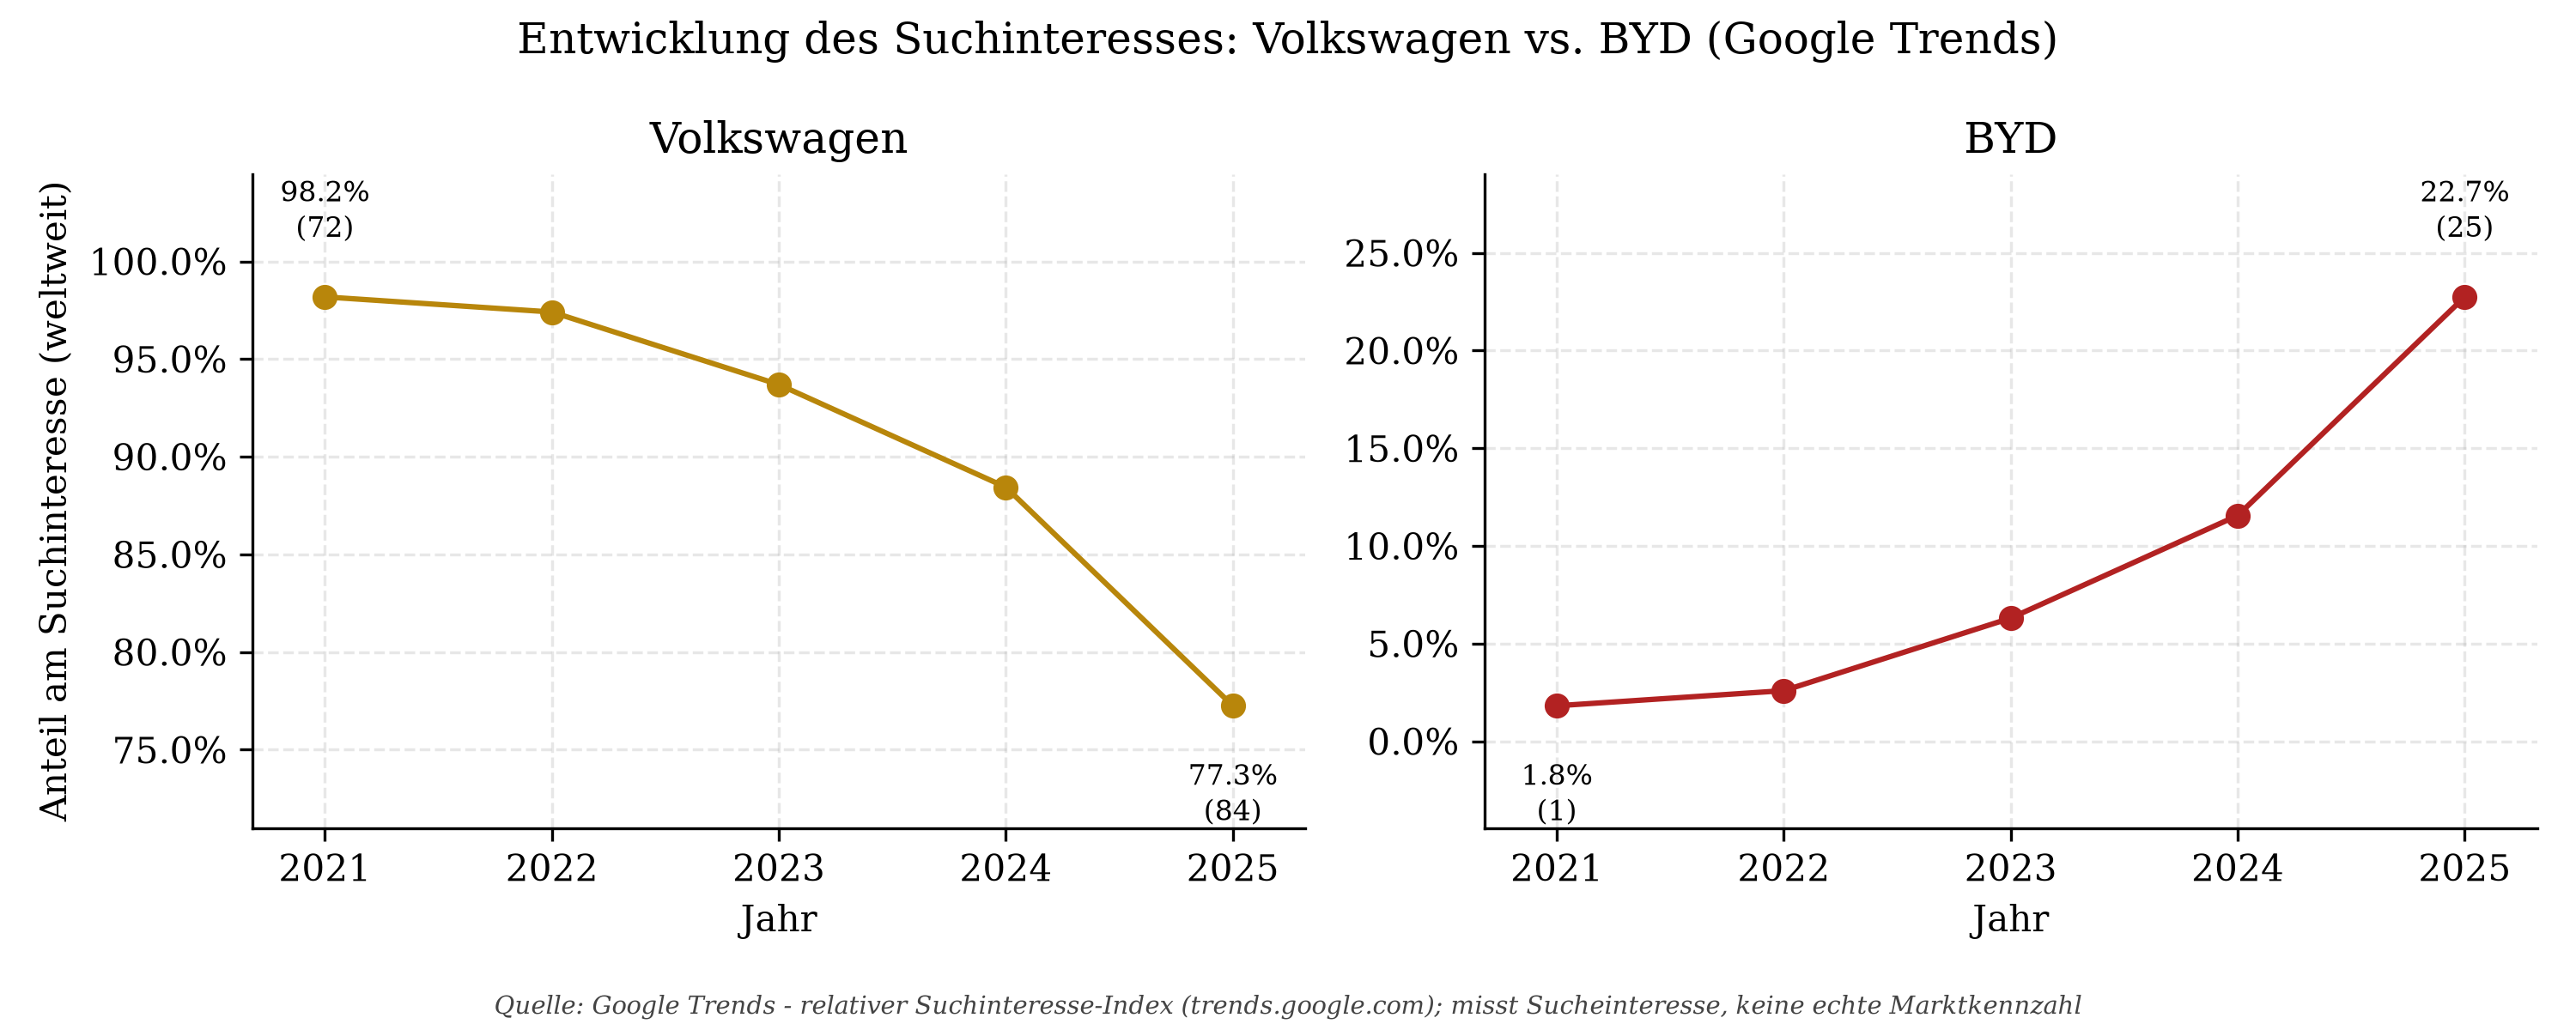

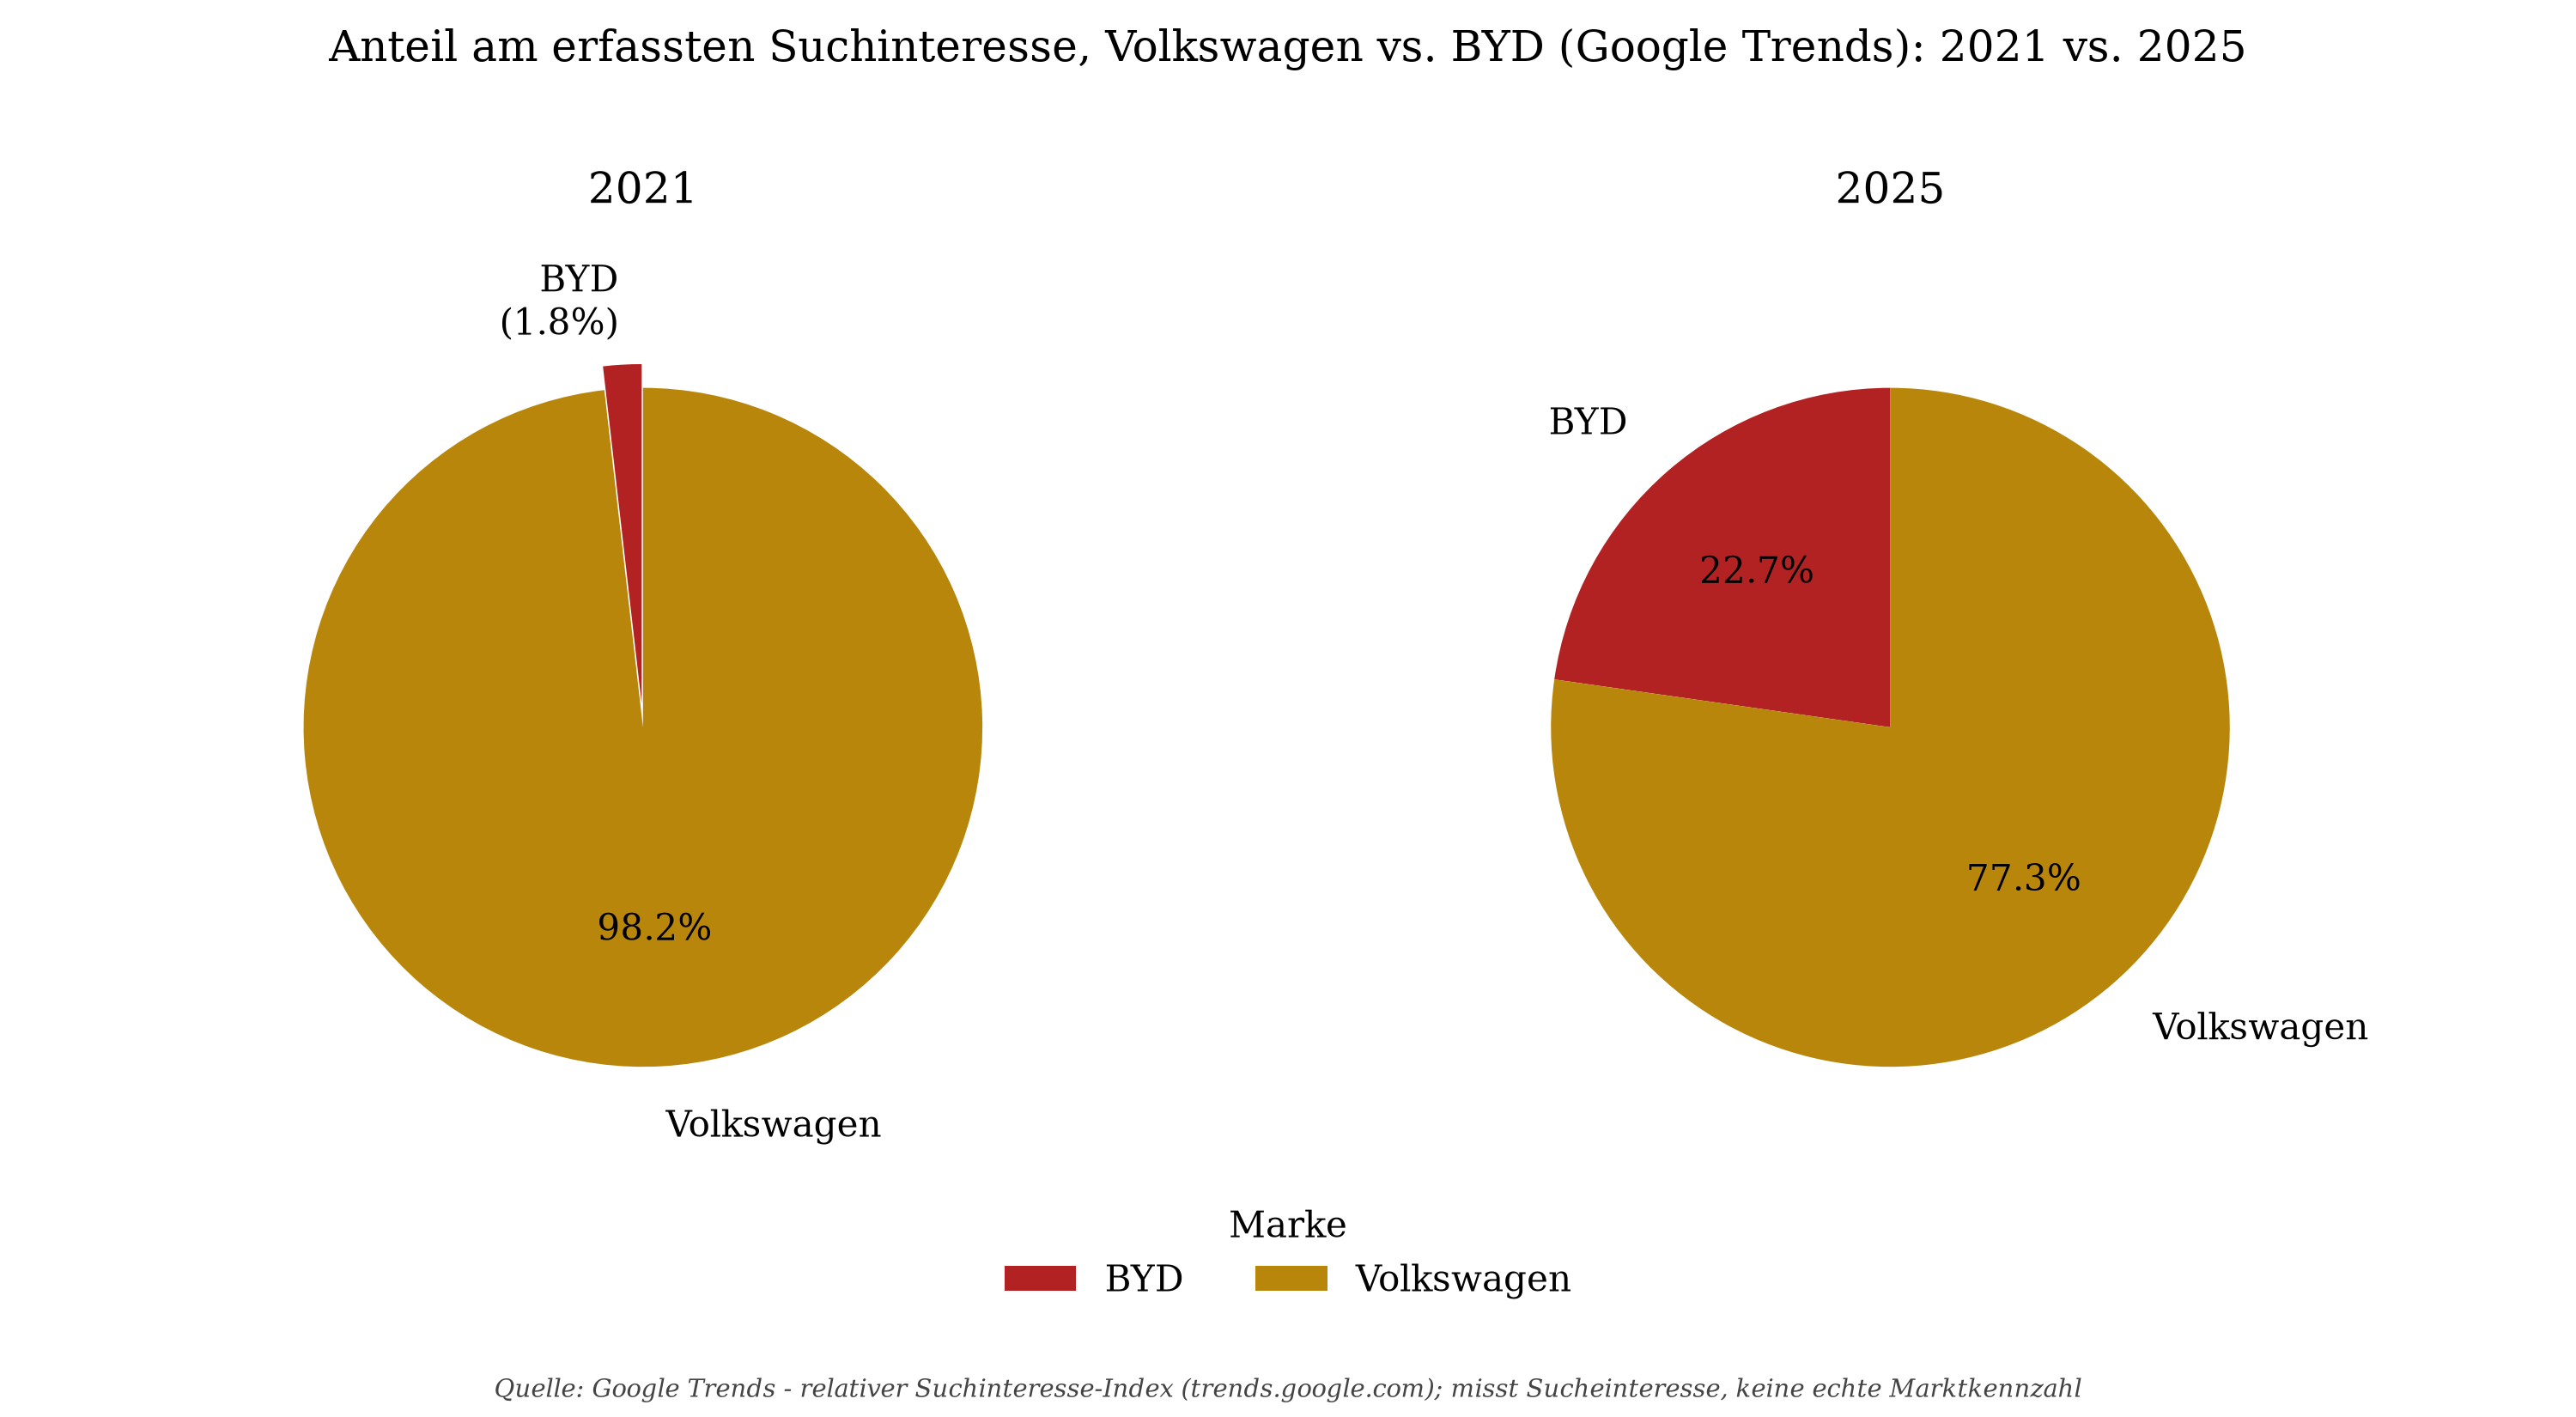

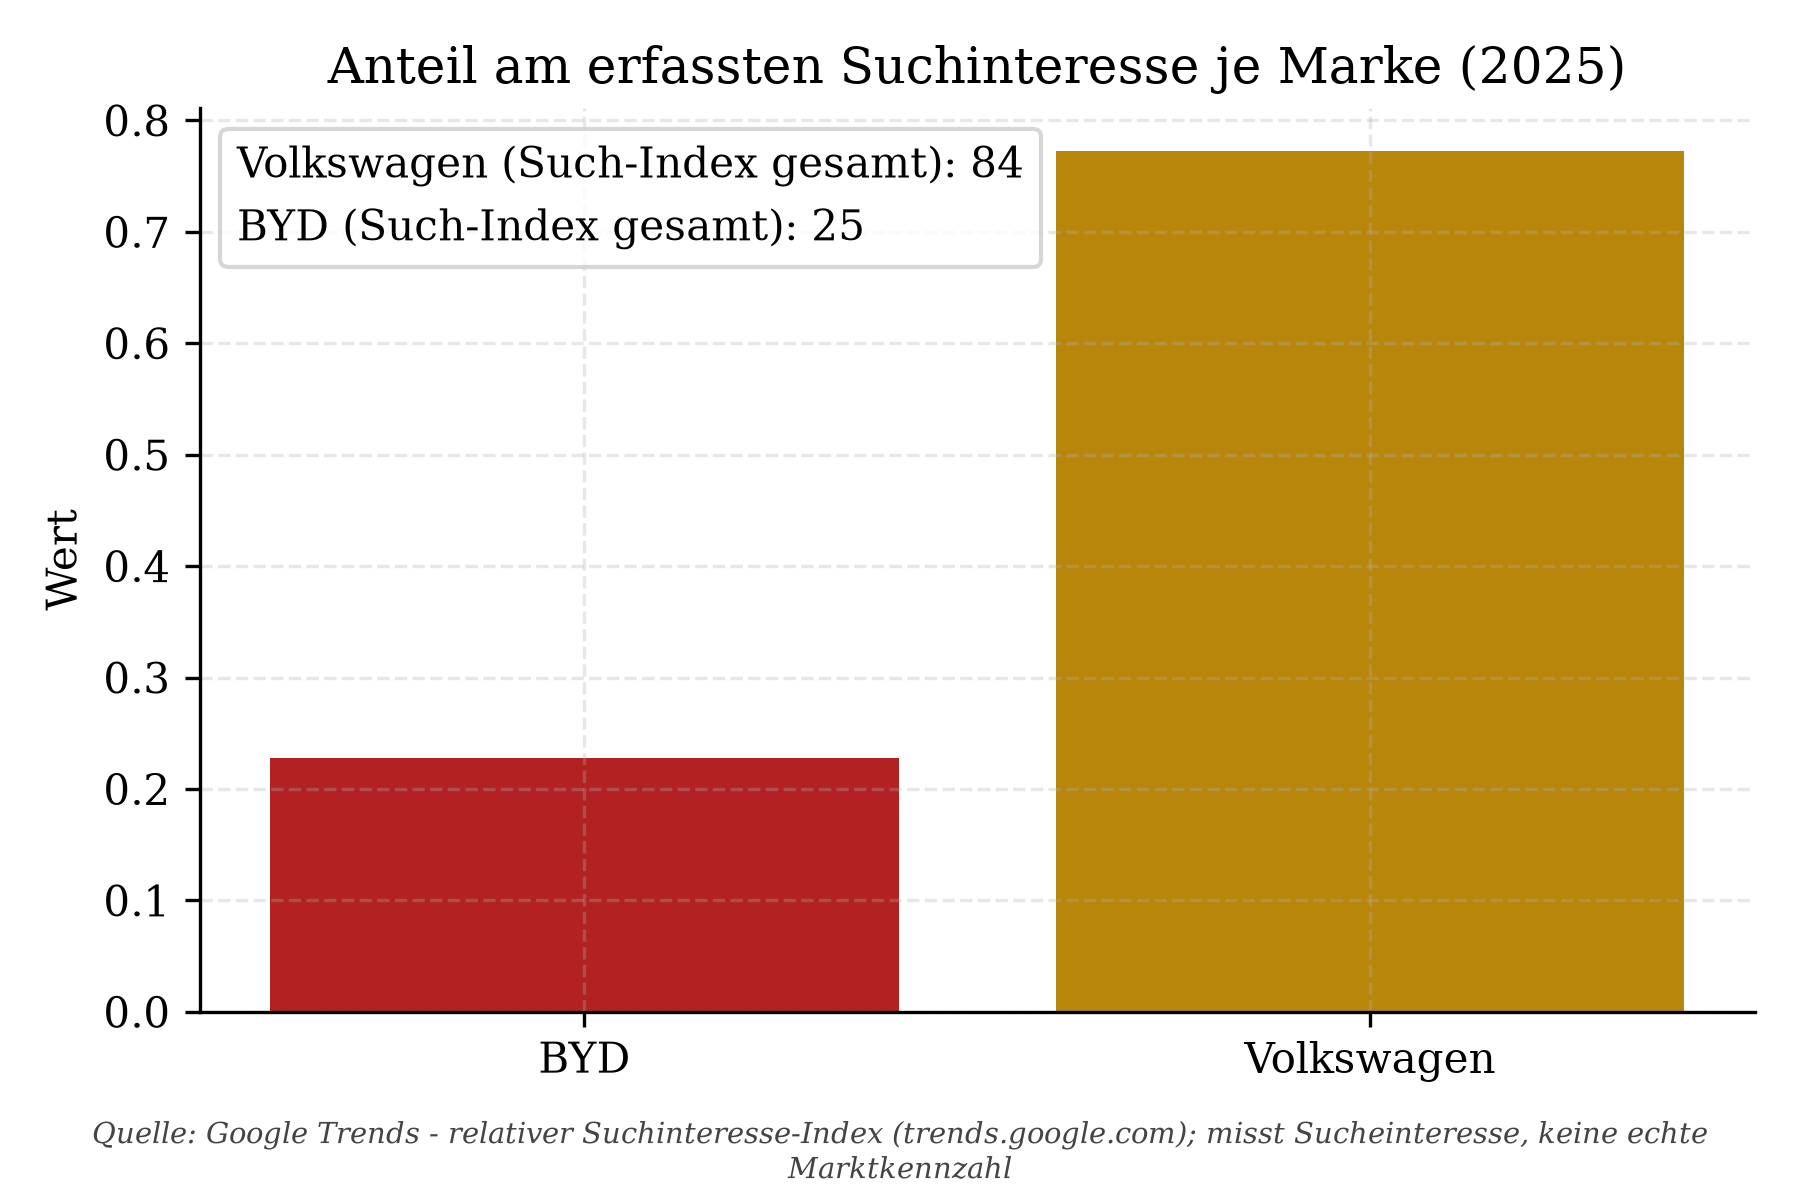

In [12]:
trends_geo = config["sources"].get("google_trends", {}).get("geo", "")
trends_geo_label = trends_geo if trends_geo else "weltweit"

# This chapter tracks exactly one brand per group (Volkswagen, BYD by default), not a
# many-brand aggregate like KBA/Switzerland -- the generic "Deutsche Marken"/"Deutsch"
# group labels the shared plotting functions default to would misleadingly imply an
# aggregate, so the brand names are used as the actual chart labels instead.
trends_group_labels = dict(
    zip(trends_frame["brand_group"], trends_frame["canonical_brand"], strict=False)
)

trends_trend_path = plot_kba_registration_trend(
    trends_frame,
    FIGURES_DIR / "trends" / "google_trends_interest_trend.png",
    share_column="google_trends_interest_share",
    count_column="search_interest_index",
    y_label=f"Anteil am Suchinteresse ({trends_geo_label})",
    suptitle="Entwicklung des Suchinteresses: Volkswagen vs. BYD (Google Trends)",
    source_note=GOOGLE_TRENDS_SOURCE_NOTE,
    group_labels=trends_group_labels,
)

trends_first_period = trends_frame["reporting_period"].min()
trends_last_period = trends_frame["reporting_period"].max()
trends_pie_path = plot_kba_share_pie_charts(
    trends_frame,
    FIGURES_DIR / "trends" / "google_trends_share_pie_first_last.png",
    share_column="google_trends_interest_share",
    suptitle=(
        "Anteil am erfassten Suchinteresse, Volkswagen vs. BYD (Google Trends): "
        f"{trends_first_period} vs. {trends_last_period}"
    ),
    source_note=GOOGLE_TRENDS_SOURCE_NOTE,
    group_labels=trends_group_labels,
    legend_title="Marke",
)

trends_latest = trends_frame[trends_frame["reporting_period"] == trends_last_period]
trends_interest_share = dict(
    zip(
        trends_latest["canonical_brand"],
        trends_latest["google_trends_interest_share"],
        strict=False,
    )
)
trends_brand_to_group = dict(
    zip(trends_latest["canonical_brand"], trends_latest["brand_group"], strict=False)
)
trends_bar_colors = [
    BRAND_GROUP_COLORS.get(trends_brand_to_group.get(brand), "#219ebc")
    for brand in trends_interest_share
]
trends_group_totals = trends_latest.groupby("brand_group")["search_interest_index"].sum()
trends_legend_notes = [
    f"{trends_group_labels.get('german', 'Deutsche Marke')} (Such-Index gesamt): "
    f"{trends_group_totals.get('german', 0):.0f}",
    f"{trends_group_labels.get('chinese', 'Chinesische Marke')} (Such-Index gesamt): "
    f"{trends_group_totals.get('chinese', 0):.0f}",
]
trends_share_path = create_report_placeholder(
    FIGURES_DIR / "frequency" / "google_trends_share_latest.png",
    metrics=trends_interest_share,
    title=f"Anteil am erfassten Suchinteresse je Marke ({trends_last_period})",
    bar_colors=trends_bar_colors,
    legend_notes=trends_legend_notes,
    source_note=GOOGLE_TRENDS_SOURCE_NOTE,
)

display(Image(filename=str(trends_trend_path)))
display(Image(filename=str(trends_pie_path)))
display(Image(filename=str(trends_share_path)))

## Zusammenfassung

Dieses Kapitel misst öffentliches Sucheinteresse (Google Trends) an nur zwei Flaggschiff-Marken
(Volkswagen, BYD) -- ein bewusst richtungsweisender Indikator, kein umfassender Markenvergleich
wie in den KBA-/Schweiz-Kapiteln (siehe "Bewusst auf zwei Marken begrenzt" oben und README's
"Google Trends"-Abschnitt für die technischen Gründe). Die KBA- und Schweiz-Kapitel oben bleiben
die einzigen Quellen für reale Neuzulassungen. Ein Vergleich beider Perspektiven zeigt, ob ein
wachsendes Sucheinteresse an BYD bereits in entsprechenden Neuzulassungen sichtbar wird oder
ihnen (noch) vorausläuft; belastbare Aussagen dazu erfordern jedoch mehrjährige, vollständige
Zeitreihen aus allen drei Quellen sowie Vorsicht bei der Interpretation, da Google Trends nur
einen relativen Index liefert und keine absoluten Suchvolumina. Zeitreihe und Abbildungen werden
unter `artifacts/` gespeichert; `scripts/download_google_trends.py` und
`scripts/generate_trends_figures.py` bieten denselben Ablauf als reproduzierbare
Kommandozeilen-Einstiegspunkte.
